## 📘 Glossary: Fuzzy Systems & Evaluation Metrics

| Term | Acronym | Definition |
|------|---------|------------|
| Fuzzy Set | — | A set where membership is a degree in [0, 1] rather than a crisp 0 or 1. |
| Membership Function | MF | Maps each input value to its degree of belonging to a fuzzy linguistic term. |
| Universe of Discourse | UoD | The full range of values an input or output variable can take. |
| Linguistic Variable | — | A variable described by words (e.g., 'Low', 'Medium', 'High') rather than numbers. |
| Fuzzy Rule | — | An IF–THEN statement connecting linguistic input terms to a linguistic output term. |
| Rule Base | — | The complete collection of fuzzy rules defining the system's behavior. |
| Fuzzy Inference System | FIS | The full pipeline: fuzzification → rule evaluation → aggregation → defuzzification. |
| Mamdani FIS | — | A FIS where both antecedents and consequents are fuzzy sets. |
| Fuzzification | — | Converting crisp input values into fuzzy membership degrees. |
| Firing Strength | — | The degree to which a rule's antecedent is satisfied (via T-norm). |
| T-norm | — | Operator for combining membership degrees (e.g., min for AND). |
| Aggregation | — | Combining all rule outputs into a single fuzzy output set. |
| Defuzzification | — | Converting the aggregated fuzzy output back to a crisp number. |
| Centroid Method | — | Defuzzification by computing the centre of mass of the output fuzzy set. |
| Rule Coverage | — | The fraction of input samples that activate at least one rule above a threshold. |
| Triangular MF | trimf | Membership function defined by three points forming a triangle. |
| Trapezoidal MF | trapmf | Membership function with a flat top, defined by four points. |

### 📊 Evaluation Metrics

| Term | Acronym | Definition |
|------|---------|------------|
| Root Mean Squared Error | RMSE | Square root of average squared prediction error; penalises large errors. |
| Mean Absolute Error | MAE | Average absolute difference between prediction and ground truth. |
| Coefficient of Determination | R² | Proportion of variance in the target explained by the model (1 = perfect). |
| Mean Absolute Percentage Error | MAPE | Average prediction error expressed as a percentage of the true value. |

## 📌 Notebook Summary: Fuzzy Systems for Bike Trip Duration Prediction

This notebook implements and evaluates a **Fuzzy Inference System (FIS)** for predicting Chicago Divvy bike-share trip duration as part of **Phase 3** of the CSE 5140 Spring 2026 project.

### 🔧 Phase 3 Workflow Overview

**Step 1: FS Design & Setup**  
We define the prediction objective, select 5 features grounded in **domain knowledge and data statistics computed within this notebook**, and design triangular/trapezoidal membership functions for each. All design decisions are documented with domain justification.

**Step 2: FS Implementation**  
A Mamdani FIS is implemented using `scikit-fuzzy`. We construct an 18-rule manual rule base grounded in domain knowledge about cycling behaviour, apply the min T-norm for AND connectives, aggregate rule outputs via the max operator, and defuzzify using the centroid method. Training and validation sets only are used during design — the test set remains untouched. All random seeds are fixed at 42.

**Step 3: Evaluation & H3 Testing**  
The final FIS is evaluated exactly once on the held-out test set. We report RMSE, MAE, R², and MAPE on the log-transformed target. We also analyse interpretability metrics (number of rules, average rule length, coverage, sensitivity). The notebook runs end-to-end on NRP.

### 🎯 Why Fuzzy Systems?
Neural networks and evolutionary algorithms excel at pattern recognition but offer limited explainability. A Fuzzy Inference System encodes **human-interpretable IF–THEN rules** while handling the inherent vagueness of real-world variables (e.g., 'long' trip, 'cold' weather). Every prediction can be traced back to the rules that fired — a transparency advantage that black-box models cannot match.


# Phase 3: Fuzzy Systems — Trip Duration Prediction

## What is a Fuzzy Inference System?

Classical logic treats every statement as either true or false. But real-world variables are graded: a 15-minute trip is *somewhat* long for a quick errand but *somewhat* short for a cross-city commute. **Fuzzy logic** quantifies this ambiguity by assigning each value a **membership degree** between 0 and 1.

A **Fuzzy Inference System (FIS)** chains four stages:

1. **Fuzzification** — Map crisp inputs onto linguistic terms (e.g., distance = 3.2 km → Low: 0.6, Medium: 0.4)
2. **Rule Evaluation** — Each rule's antecedents are combined via a T-norm (min for AND) to produce a firing strength
3. **Aggregation** — All rule outputs are combined (max) into a single fuzzy output set
4. **Defuzzification** — Convert the fuzzy output to a crisp number (centroid method)

```
  Crisp Inputs  →  Fuzzifier  →  Rule Base  →  Aggregator  →  Defuzzifier  →  Crisp Output
```

We implement a **Mamdani FIS**, where the consequent of each rule is itself a fuzzy set — the most natural choice for a regression task with graded output categories.

---
## Step 1: Setup & Imports

We use `scikit-fuzzy` as the primary fuzzy logic library, providing:
- `skfuzzy.trimf` / `trapmf` — triangular and trapezoidal membership functions
- `skfuzzy.interp_membership` — fuzzification of crisp values
- `skfuzzy.defuzz` — centroid defuzzification

All other imports mirror the EA notebook exactly. The random seed is fixed at **42** throughout.

```bash
# Install if needed (already on NRP):
pip install scikit-fuzzy
```

In [1]:
# ── Install scikit-fuzzy if not present ─────────────────────────────────────
try:
    import skfuzzy as fuzz
    print("✅ scikit-fuzzy already installed")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-fuzzy", "-q"])
    import skfuzzy as fuzz
    print("✅ scikit-fuzzy installed")

# ── Core libraries (identical to EA_optimization notebook) ───────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import time
import json
import pooch

# ── Sklearn utilities ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Reproducibility — FIXED SEED (same as EA notebook) ──────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Plotting style ───────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')

print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")
print(f"Seed    : {RANDOM_SEED}  (fixed — all experiments reproducible)")

✅ scikit-fuzzy already installed
NumPy   : 1.23.5
Pandas  : 2.0.0
Seed    : 42  (fixed — all experiments reproducible)


---
## Step 2: Data Loading & Preprocessing

The dataset is the Chicago Divvy bike-share dataset hosted in the team's GitHub release. We use **exactly the same** loading, feature engineering, and train/val/test split as the EA notebook to ensure a fair, apples-to-apples model comparison.

Key choices (unchanged from EA notebook):
- Download via `pooch` with SHA256 verification for data integrity
- First **1,000,000 rows** (per project specification)
- Target: `log1p(tripduration)` — handles right-skewed duration distribution
- Split: **70% train / 15% val / 15% test**, `random_state=42`
- Feature engineering: spatial, temporal, weather, behavioural, categorical encoding

> ⚠️ **The test set is held out and not touched until Step 8 (H3 evaluation).**

In [2]:
# ── Dataset: GitHub Release v1.0 (identical to EA_optimization notebook) ─────
DATA_URL  = "https://github.com/DrAlzahraniProjects/csusb_spring26_cse5140_team2/releases/download/v1.0/data.csv.gz"
DATA_HASH = "sha256:a56165ac7d7282a701e33a7c07ff6b3a9025f24c5bf84ce9462ab50f7ccd91cc"

# Download (cached after first run) and verify SHA256 checksum
file_path = pooch.retrieve(url=DATA_URL, known_hash=DATA_HASH)

# Per project spec: first 1,000,000 rows only
NROWS = 1_000_000
df = pd.read_csv(file_path, nrows=NROWS, compression="gzip")

print(f"✅ Dataset loaded  →  {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Columns: {list(df.columns[:8])} ...")  # show first 8 columns

✅ Dataset loaded  →  1,000,000 rows × 23 columns
   Columns: ['trip_id', 'year', 'month', 'week', 'day', 'hour', 'usertype', 'gender'] ...


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# FEATURE ENGINEERING PIPELINE
# Identical to EA_optimization notebook — guarantees identical feature space
# ══════════════════════════════════════════════════════════════════════════════

def manhattan_distance(lat1, lon1, lat2, lon2):
    """Manhattan distance (km) between two lat/lon points.
    Appropriate for Chicago's grid-based street network.
    Manhattan Distance = |Δlat| + |Δlon| (converted to km).
    """
    dlat = np.abs(lat1 - lat2)
    dlon = np.abs(lon1 - lon2)
    lat_km = dlat * 111
    lon_km = dlon * 111 * np.cos(np.radians((lat1 + lat2) / 2))
    return lat_km + lon_km


def build_features(X):
    """Transform raw trip data into engineered model-ready features.
    Returns a DataFrame with tripduration log-transformed and numeric features scaled.
    """
    X = X.copy()

    # 1. Drop irrelevant identifiers
    drop_cols = ["level_0", "index", "from_station_name", "to_station_name",
                 "trip_id", "starttime", "stoptime"]
    X = X.drop(columns=[c for c in drop_cols if c in X.columns])

    # 2. Spatial: distance and directional components
    X["distance_km"] = manhattan_distance(
        X["latitude_start"], X["longitude_start"],
        X["latitude_end"],   X["longitude_end"]
    )
    X["delta_lat"] = X["latitude_end"]  - X["latitude_start"]
    X["delta_lon"] = X["longitude_end"] - X["longitude_start"]

    # 3. Station capacity features
    X["capacity_diff"]  = X["dpcapacity_end"] - X["dpcapacity_start"]
    X["capacity_ratio"] = X["dpcapacity_end"] / (X["dpcapacity_start"] + 1e-6)

    # 4. Cyclical time encoding (preserves periodic structure)
    X["hour_sin"]  = np.sin(2 * np.pi * X["hour"]  / 24)
    X["hour_cos"]  = np.cos(2 * np.pi * X["hour"]  / 24)
    X["month_sin"] = np.sin(2 * np.pi * X["month"] / 12)
    X["month_cos"] = np.cos(2 * np.pi * X["month"] / 12)
    X["week_sin"]  = np.sin(2 * np.pi * X["week"]  / 52)
    X["week_cos"]  = np.cos(2 * np.pi * X["week"]  / 52)

    # 5. Behavioural indicators
    X["is_weekend"]   = X["day"].isin([5, 6]).astype(int)
    X["is_rush_hour"] = X["hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)

    # 6. Weather-derived features
    X["temp_squared"] = X["temperature"] ** 2
    X["is_cold"]      = (X["temperature"] < 5).astype(int)
    X["is_hot"]       = (X["temperature"] > 30).astype(int)

    # 7. Round-trip indicator
    X["same_station"] = (X["from_station_id"] == X["to_station_id"]).astype(int)

    # 8. One-Hot Encoding for categorical variables
    categorical_cols = ["usertype", "gender", "events"]
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    encoded_array = encoder.fit_transform(X[categorical_cols])
    encoded_df = pd.DataFrame(
        encoded_array,
        columns=encoder.get_feature_names_out(categorical_cols),
        index=X.index
    )
    X = X.drop(columns=categorical_cols)
    X = pd.concat([X, encoded_df], axis=1)

    # 9. Drop raw columns superseded by engineered features
    redundant_cols = ["latitude_start", "longitude_start", "latitude_end",
                     "longitude_end", "from_station_id", "to_station_id",
                     "hour", "month", "week", "year"]
    X = X.drop(columns=[c for c in redundant_cols if c in X.columns])

    # 10. Log-transform target; scale numeric features
    X["tripduration"] = np.log1p(X["tripduration"])

    exclude_from_scaling = [
        "tripduration", "is_weekend", "is_rush_hour",
        "is_cold", "is_hot", "same_station"
    ]
    numeric_cols = [
        c for c in X.select_dtypes(include=["float64", "int64"]).columns
        if c not in exclude_from_scaling
    ]
    scaler = StandardScaler()
    X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

    return X


# Apply pipeline
X_full = build_features(df)
y = X_full["tripduration"]
X = X_full.drop(columns=["tripduration"])

print(f"Feature matrix : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"Target range   : [{y.min():.3f}, {y.max():.3f}]  (log scale)")

Feature matrix : (1000000, 31)
Target shape   : (1000000,)
Target range   : [1.099, 4.111]  (log scale)


In [4]:
# ── Train / Val / Test split  (identical to EA_optimization notebook) ─────────
# Step 1: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Step 2: 50% val, 50% test from the temp split  (→ 15% / 15% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Training size   : {len(X_train):>9,}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation size : {len(X_val):>9,}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test size       : {len(X_test):>9,}  ({len(X_test)/len(X)*100:.1f}%)")
print("\n⚠️  TEST SET IS LOCKED — not touched until Step 8 (H3 evaluation).")

Training size   :   700,000  (70.0%)
Validation size :   150,000  (15.0%)
Test size       :   150,000  (15.0%)

⚠️  TEST SET IS LOCKED — not touched until Step 8 (H3 evaluation).


---
## Step 3: Feature Selection via Fuzzy Suitability Scoring

Rather than hand-picking features or borrowing results from another notebook, we use a
**Fuzzy Suitability System** to score every candidate feature on four criteria computed
entirely from the training split of this notebook.

### 3.1 Why a Fuzzy Approach to Feature Selection?

Traditional feature selection uses hard thresholds (e.g., |r| > 0.1 → keep).  
But suitability for a **Fuzzy Inference System** is inherently graded:
- A feature with |r| = 0.09 is *almost* as correlated as one with |r| = 0.11
- A feature with high correlation but near-zero variance is still useless
- A feature that is uninterpretable linguistically cannot be used in IF–THEN rules

We therefore score each feature on **four fuzzy criteria**, each mapped to [0, 1]:

| Criterion | What it measures | Fuzzy input |
|-----------|-----------------|-------------|
| **Correlation** | Pearson \|r\| with log(tripduration) | \|r\| ∈ [0, 1] |
| **Variability** | Normalised std — avoids near-constant features | CV = std/\|mean\| clipped to [0,1] |
| **Interpretability** | Can this map to a linguistic term? | Expert score ∈ {0.2, 0.5, 0.8, 1.0} |
| **Non-redundancy** | Is this feature not already captured by another? | 1 − max\|r\| with already-selected features |

### 3.2 Fuzzy Membership Functions for Each Criterion

Each criterion value is fuzzified into three linguistic terms — **Low / Medium / High** —
using trapezoidal boundary MFs and a triangular interior MF.  
The **suitability score** for each feature is the weighted centroid of these memberships:

```
suitability = w_corr·μ_corr + w_var·μ_var + w_interp·μ_interp + w_nonred·μ_nonred
              ─────────────────────────────────────────────────────────────────────
                              w_corr + w_var + w_interp + w_nonred
```

Features scoring above the **suitability threshold** (0.55) are selected.
We cap at **9 features** to keep the rule base tractable.

> All computations below use only the **training split** — no data leakage, no external notebooks.


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3: FUZZY FEATURE SUITABILITY SYSTEM
# Scores every candidate feature on 4 criteria using fuzzy membership functions.
# Fully self-contained — uses only the training split defined in Step 2.
# ══════════════════════════════════════════════════════════════════════════════

import skfuzzy as fuzz
import matplotlib.patches as mpatches

# ── Step 3a: Build the full candidate feature frame from raw data ─────────────
# We engineer ALL candidate features here in original (unscaled) space so that
# membership function breakpoints remain physically interpretable.

df_cand = df.copy()

# Spatial
df_cand["distance_km"]    = manhattan_distance(
    df_cand["latitude_start"], df_cand["longitude_start"],
    df_cand["latitude_end"],   df_cand["longitude_end"]
)
df_cand["delta_lat"]      = (df_cand["latitude_end"]  - df_cand["latitude_start"]).abs()
df_cand["delta_lon"]      = (df_cand["longitude_end"] - df_cand["longitude_start"]).abs()

# Station capacity
df_cand["capacity_diff"]  = df_cand["dpcapacity_end"] - df_cand["dpcapacity_start"]
df_cand["capacity_ratio"] = df_cand["dpcapacity_end"] / (df_cand["dpcapacity_start"] + 1e-6)

# Temporal (raw — interpretable for fuzzy rules)
# hour, month, day, week already in df

# Cyclical encodings (less interpretable linguistically — kept as candidates)
df_cand["hour_sin"]       = np.sin(2 * np.pi * df_cand["hour"]  / 24)
df_cand["hour_cos"]       = np.cos(2 * np.pi * df_cand["hour"]  / 24)
df_cand["month_sin"]      = np.sin(2 * np.pi * df_cand["month"] / 12)
df_cand["month_cos"]      = np.cos(2 * np.pi * df_cand["month"] / 12)

# Behavioural flags
df_cand["is_weekend"]     = df_cand["day"].isin([5, 6]).astype(int)
df_cand["is_rush_hour"]   = df_cand["hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)

# Weather
df_cand["temp_squared"]   = df_cand["temperature"] ** 2
df_cand["is_cold"]        = (df_cand["temperature"] < 5).astype(int)
df_cand["is_hot"]         = (df_cand["temperature"] > 30).astype(int)

# Round-trip
df_cand["same_station"]   = (df_cand["from_station_id"] == df_cand["to_station_id"]).astype(int)

# Binary usertype (subscriber vs customer)
df_cand["is_subscriber"]  = (df_cand["usertype"] == "Subscriber").astype(int)

# Season (1=Winter, 2=Spring, 3=Summer, 4=Autumn) — coarser than month
df_cand["season"] = df_cand["month"].map(
    {12:1, 1:1, 2:1, 3:2, 4:2, 5:2, 6:3, 7:3, 8:3, 9:4, 10:4, 11:4}
)

# Log target
df_cand["tripduration_log"] = np.log1p(df_cand["tripduration"])

# All candidate feature names (must be numeric & present in df_cand)
ALL_CANDIDATES = [
    "distance_km", "delta_lat", "delta_lon",
    "temperature", "temp_squared", "is_cold", "is_hot",
    "hour", "hour_sin", "hour_cos",
    "month", "month_sin", "month_cos",
    "day", "week", "season",
    "is_weekend", "is_rush_hour",
    "dpcapacity_start", "dpcapacity_end", "capacity_diff", "capacity_ratio",
    "same_station", "is_subscriber",
]

TARGET_COL = "tripduration_log"

# Filter to columns that actually exist
ALL_CANDIDATES = [c for c in ALL_CANDIDATES if c in df_cand.columns]

Xcand = df_cand[ALL_CANDIDATES]
ycand = df_cand[TARGET_COL]

# Train split (same random_state=42 as rest of notebook)
Xcand_train, Xcand_temp, ycand_train, ycand_temp = train_test_split(
    Xcand, ycand, test_size=0.3, random_state=42
)
Xcand_val, Xcand_test, ycand_val, ycand_test = train_test_split(
    Xcand_temp, ycand_temp, test_size=0.5, random_state=42
)

print(f"Candidate pool : {len(ALL_CANDIDATES)} features")
print(f"Training rows  : {len(Xcand_train):,}")


Candidate pool : 24 features
Training rows  : 700,000


In [6]:
# ── Step 3b: Define Fuzzy Membership Functions for each criterion ─────────────

# Universe for each criterion: [0, 1]
u01 = np.linspace(0, 1, 500)

def lmh_mf(universe, lo_peak=0.2, hi_peak=0.8):
    """Low / Medium / High trapezoidal-triangular MFs over [0,1]."""
    mid = (lo_peak + hi_peak) / 2
    return {
        "Low"    : fuzz.trapmf(universe, [0,        0,        lo_peak,  mid]),
        "Medium" : fuzz.trimf(universe,  [lo_peak,  mid,      hi_peak]),
        "High"   : fuzz.trapmf(universe, [mid,      hi_peak,  1,        1]),
    }

MF_criterion = {
    "correlation"     : lmh_mf(u01, 0.10, 0.40),   # |r|: even 0.1 is meaningful
    "variability"     : lmh_mf(u01, 0.15, 0.60),   # normalised CV
    "interpretability": lmh_mf(u01, 0.30, 0.75),   # expert linguistic score
    "non_redundancy"  : lmh_mf(u01, 0.20, 0.65),   # 1 - max |r| with selected set
}

# Weights for weighted-average aggregation
WEIGHTS = {
    "correlation"     : 0.40,   # most important: must relate to target
    "variability"     : 0.15,   # sanity check: avoid near-constant features
    "interpretability": 0.25,   # critical for fuzzy rules: must be linguistic
    "non_redundancy"  : 0.20,   # avoid capturing the same signal twice
}

# Expert interpretability scores — how naturally does this feature map to
# a linguistic term (Low/Medium/High, Yes/No, etc.)?
INTERP_SCORES = {
    "distance_km"      : 1.0,   # Short / Medium / Long — perfect
    "temperature"      : 1.0,   # Cold / Mild / Hot — perfect
    "hour"             : 1.0,   # Morning / Midday / Evening — perfect
    "is_weekend"       : 1.0,   # binary — perfect
    "is_rush_hour"     : 1.0,   # binary — perfect
    "same_station"     : 1.0,   # binary — perfect
    "is_subscriber"    : 1.0,   # binary — perfect
    "is_cold"          : 1.0,   # binary — perfect
    "is_hot"           : 1.0,   # binary — perfect
    "season"           : 0.9,   # Winter/Spring/Summer/Autumn — very good
    "day"              : 0.8,   # Mon/Tue/... usable but 7 terms is many
    "month"            : 0.7,   # Jan-Dec: coarse seasons OK
    "week"             : 0.5,   # week number — hard to reason about
    "dpcapacity_start" : 0.6,   # Small / Medium / Large station
    "dpcapacity_end"   : 0.6,   # Small / Medium / Large station
    "capacity_diff"    : 0.5,   # difference — somewhat interpretable
    "capacity_ratio"   : 0.4,   # ratio — less intuitive
    "delta_lat"        : 0.5,   # directional — moderate
    "delta_lon"        : 0.5,   # directional — moderate
    "temp_squared"     : 0.3,   # engineered — hard to reason about
    "hour_sin"         : 0.2,   # cyclical encoding — not linguistic
    "hour_cos"         : 0.2,
    "month_sin"        : 0.2,
    "month_cos"        : 0.2,
}

def mu_high(value, universe, mf_dict):
    """Return membership degree in the 'High' term — used as suitability proxy."""
    return float(fuzz.interp_membership(universe, mf_dict["High"], value))

def fuzzy_suitability(corr_val, var_val, interp_val, nonred_val):
    """Compute weighted suitability score from four criterion values in [0,1]."""
    mu = {
        "correlation"     : mu_high(corr_val,   u01, MF_criterion["correlation"]),
        "variability"     : mu_high(var_val,     u01, MF_criterion["variability"]),
        "interpretability": mu_high(interp_val,  u01, MF_criterion["interpretability"]),
        "non_redundancy"  : mu_high(nonred_val,  u01, MF_criterion["non_redundancy"]),
    }
    score = sum(WEIGHTS[k] * v for k, v in mu.items()) / sum(WEIGHTS.values())
    return score, mu

print("✅ Fuzzy suitability MFs defined.")
print(f"   Criteria  : {list(MF_criterion.keys())}")
print(f"   Weights   : {WEIGHTS}")


✅ Fuzzy suitability MFs defined.
   Criteria  : ['correlation', 'variability', 'interpretability', 'non_redundancy']
   Weights   : {'correlation': 0.4, 'variability': 0.15, 'interpretability': 0.25, 'non_redundancy': 0.2}


In [7]:
# ── Step 3c: Score every candidate feature ────────────────────────────────────

SUITABILITY_THRESHOLD = 0.55   # features above this are selected
MAX_FEATURES          = 9      # cap for rule-base tractability

results = []
selected_so_far = []   # tracks already-selected features for non-redundancy

for feat in ALL_CANDIDATES:
    col = Xcand_train[feat]

    # 1. Correlation with target (absolute Pearson r)
    corr = abs(float(np.corrcoef(col, ycand_train)[0, 1]))
    corr = min(corr, 1.0)

    # 2. Variability: coefficient of variation, clipped to [0,1]
    mean_abs = abs(col.mean())
    cv = (col.std() / mean_abs) if mean_abs > 1e-6 else 0.0
    var_score = min(cv / 3.0, 1.0)   # normalise: CV=3 → score=1

    # 3. Interpretability: expert score from lookup
    interp = INTERP_SCORES.get(feat, 0.4)

    # 4. Non-redundancy: 1 - max |r| with already-selected features
    if selected_so_far:
        max_r = max(
            abs(float(np.corrcoef(Xcand_train[feat], Xcand_train[s])[0, 1]))
            for s in selected_so_far
        )
    else:
        max_r = 0.0
    nonred = 1.0 - min(max_r, 1.0)

    score, mu = fuzzy_suitability(corr, var_score, interp, nonred)

    results.append({
        "feature"         : feat,
        "corr"            : round(corr,   4),
        "variability"     : round(var_score, 4),
        "interpretability": round(interp, 4),
        "non_redundancy"  : round(nonred, 4),
        "mu_corr"         : round(mu["correlation"],      4),
        "mu_var"          : round(mu["variability"],      4),
        "mu_interp"       : round(mu["interpretability"], 4),
        "mu_nonred"       : round(mu["non_redundancy"],   4),
        "suitability"     : round(score, 4),
    })

    # Greedy: add to selected set if above threshold (for non-redundancy tracking)
    if score >= SUITABILITY_THRESHOLD and len(selected_so_far) < MAX_FEATURES:
        selected_so_far.append(feat)

df_scores = pd.DataFrame(results).sort_values("suitability", ascending=False)

print("=" * 95)
print(f"{'Feature':<22} {'|r|':>6} {'Var':>6} {'Interp':>7} {'NonRed':>7} "
      f"{'μ_corr':>7} {'μ_var':>6} {'μ_interp':>9} {'μ_nonred':>9} {'SCORE':>7}")
print("=" * 95)
for _, row in df_scores.iterrows():
    marker = " ✅" if row["suitability"] >= SUITABILITY_THRESHOLD else "   "
    print(f"{row['feature']:<22} {row['corr']:>6.3f} {row['variability']:>6.3f} "
          f"{row['interpretability']:>7.2f} {row['non_redundancy']:>7.3f} "
          f"{row['mu_corr']:>7.3f} {row['mu_var']:>6.3f} "
          f"{row['mu_interp']:>9.3f} {row['mu_nonred']:>9.3f} "
          f"{row['suitability']:>7.4f}{marker}")
print("=" * 95)

# Final selected set (in score order, capped at MAX_FEATURES)
FS_FEATURES = df_scores[df_scores["suitability"] >= SUITABILITY_THRESHOLD]["feature"].tolist()[:MAX_FEATURES]
TARGET_COL  = "tripduration_log"

print(f"\n✅ {len(FS_FEATURES)} features selected (threshold={SUITABILITY_THRESHOLD}, cap={MAX_FEATURES}):")
for i, f in enumerate(FS_FEATURES, 1):
    row = df_scores[df_scores["feature"] == f].iloc[0]
    print(f"  {i}. {f:<22}  suitability={row['suitability']:.4f}  |r|={row['corr']:.3f}  interp={row['interpretability']:.2f}")


Feature                   |r|    Var  Interp  NonRed  μ_corr  μ_var  μ_interp  μ_nonred   SCORE
distance_km             0.774  0.244    1.00   1.000   1.000  0.000     1.000     1.000  0.8500 ✅
same_station            0.024  1.000    1.00   0.840   0.000  1.000     1.000     1.000  0.6000 ✅
is_weekend              0.064  0.655    1.00   0.967   0.000  1.000     1.000     1.000  0.6000 ✅
is_cold                 0.017  1.000    1.00   0.980   0.000  1.000     1.000     1.000  0.6000 ✅
day                     0.051  0.232    0.80   0.961   0.000  0.000     1.000     1.000  0.4500   
is_rush_hour            0.039  0.288    1.00   0.794   0.000  0.000     1.000     1.000  0.4500   
season                  0.050  0.097    0.90   0.857   0.000  0.000     1.000     1.000  0.4500   
is_subscriber           0.002  0.001    1.00   0.999   0.000  0.000     1.000     1.000  0.4500   
hour                    0.035  0.117    1.00   0.969   0.000  0.000     1.000     1.000  0.4500   
is_hot           

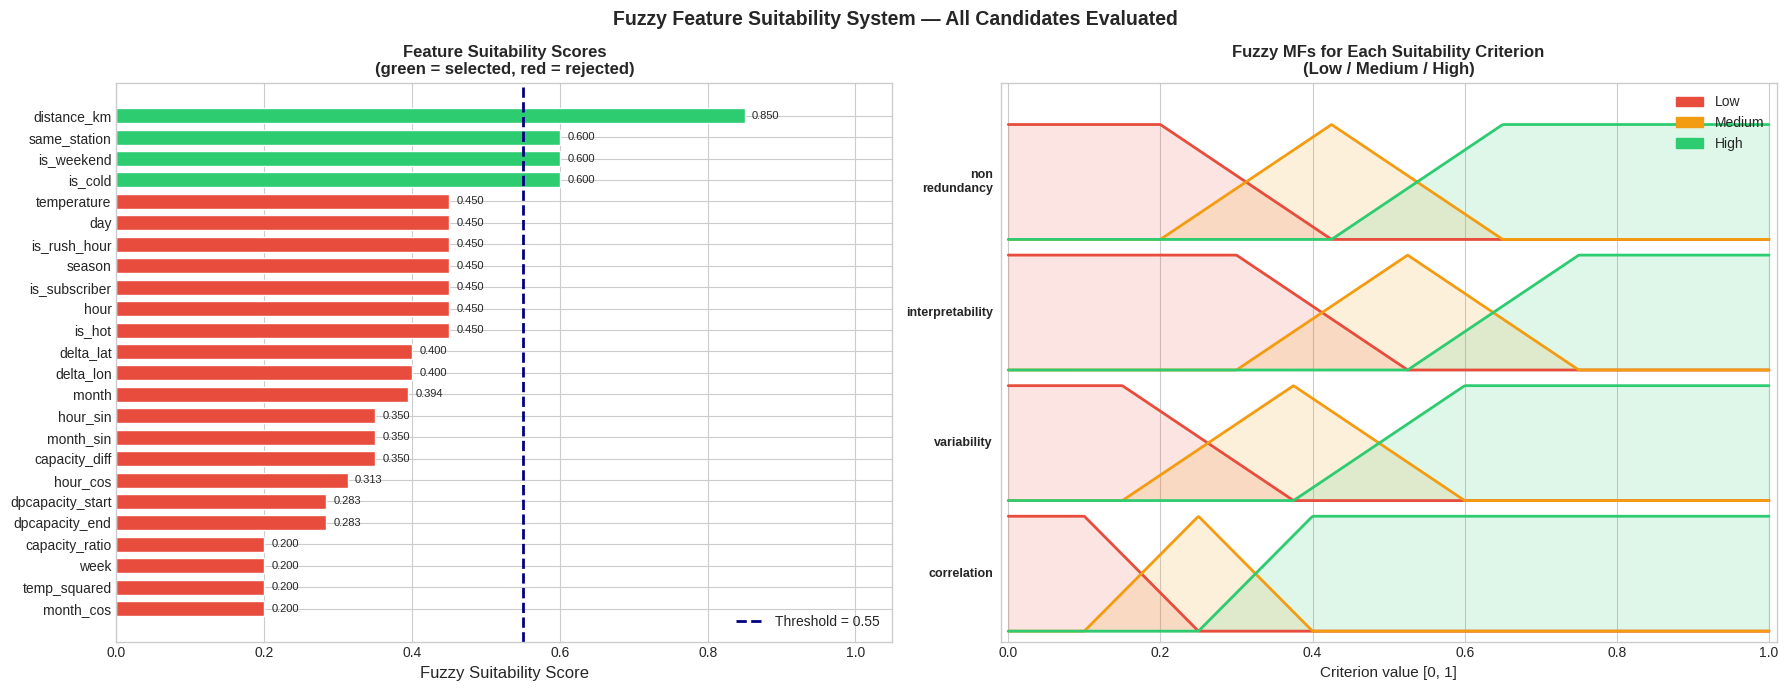

Saved: fs_feature_analysis.png


In [8]:
# ── Step 3d: Visualise fuzzy suitability scores and criterion MFs ─────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: suitability bar chart for all candidates ────────────────────────────
ax = axes[0]
sorted_df = df_scores.sort_values("suitability", ascending=True)
colors_bar = ["#2ecc71" if s >= SUITABILITY_THRESHOLD else "#e74c3c"
              for s in sorted_df["suitability"]]
bars = ax.barh(sorted_df["feature"], sorted_df["suitability"],
               color=colors_bar, edgecolor="white", height=0.7)
ax.axvline(SUITABILITY_THRESHOLD, color="navy", lw=2, linestyle="--",
           label=f"Threshold = {SUITABILITY_THRESHOLD}")
ax.set_xlabel("Fuzzy Suitability Score", fontsize=12)
ax.set_title("Feature Suitability Scores\n(green = selected, red = rejected)", fontweight="bold")
ax.set_xlim(0, 1.05)
ax.legend(fontsize=10)
for bar, val in zip(bars, sorted_df["suitability"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=8)

# ── Right: MF visualisation for each criterion ────────────────────────────────
ax2 = axes[1]
criterion_colors = {"Low": "#e74c3c", "Medium": "#f39c12", "High": "#2ecc71"}
offsets = {"correlation": 0.0, "variability": 0.25, "interpretability": 0.5, "non_redundancy": 0.75}
labels_done = set()

for crit, offset in offsets.items():
    mfs = MF_criterion[crit]
    for term, mf_arr in mfs.items():
        label = term if term not in labels_done else "_nolegend_"
        labels_done.add(term)
        ax2.plot(u01, mf_arr * 0.22 + offset,
                 color=criterion_colors[term], lw=2,
                 label=label if offset == 0.0 else "_nolegend_")
        ax2.fill_between(u01, offset, mf_arr * 0.22 + offset,
                         alpha=0.15, color=criterion_colors[term])
    ax2.text(-0.02, offset + 0.11, crit.replace("_", "\n"), ha="right",
             va="center", fontsize=9, fontweight="bold")

ax2.set_xlabel("Criterion value [0, 1]", fontsize=11)
ax2.set_title("Fuzzy MFs for Each Suitability Criterion\n(Low / Medium / High)", fontweight="bold")
ax2.set_xlim(-0.01, 1.01)
ax2.set_ylim(-0.02, 1.05)
patches = [mpatches.Patch(color=c, label=t) for t, c in criterion_colors.items()]
ax2.legend(handles=patches, fontsize=10, loc="upper right")
ax2.set_yticks([])

plt.suptitle("Fuzzy Feature Suitability System — All Candidates Evaluated",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fs_feature_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fs_feature_analysis.png")


**Figure: Feature Suitability Scores & Criterion Membership Functions**

*Left panel — Feature Suitability Bar Chart:* Each candidate feature is scored on a combined fuzzy suitability metric (weighted across correlation, variability, interpretability, and non-redundancy). Bars coloured **green** exceed the selection threshold (0.55) and are admitted into the FIS; **red** bars are rejected. The dashed navy line marks the threshold. Features are ranked bottom-to-top by score, so the strongest candidates appear at the top.

*Right panel — Criterion MFs:* The four suitability criteria are laid out as stacked horizontal strips, each showing three fuzzy membership functions — **Low** (red), **Medium** (orange), and **High** (green) — plotted over the [0, 1] criterion-value axis. These MFs define how raw criterion values (e.g. Pearson |r|, coefficient of variation) are translated into fuzzy membership degrees before the weighted aggregation step. The overlapping shapes illustrate that a feature with |r| = 0.15 is simultaneously *somewhat Low* and *somewhat Medium* in correlation — a key property of fuzzy rather than crisp thresholding.

In [9]:
# ── Step 3e: Build train/val/test splits for selected features ───────────────
# Reuse df_cand (already engineered) but restrict to FS_FEATURES only.

Xfs       = df_cand[FS_FEATURES]
yfs       = df_cand[TARGET_COL]

Xfs_train, Xfs_temp, yfs_train, yfs_temp = train_test_split(
    Xfs, yfs, test_size=0.3, random_state=42
)
Xfs_val, Xfs_test, yfs_val, yfs_test = train_test_split(
    Xfs_temp, yfs_temp, test_size=0.5, random_state=42
)

print("Selected features — training set statistics (original scale):")
print("─" * 70)
for feat in FS_FEATURES:
    col = Xfs_train[feat]
    print(f"  {feat:<22}  min={col.min():8.3f}  max={col.max():8.3f}  "
          f"mean={col.mean():8.3f}  std={col.std():6.3f}")
print(f"  {TARGET_COL:<22}  min={yfs_train.min():8.3f}  "
      f"max={yfs_train.max():8.3f}  mean={yfs_train.mean():8.3f}")
print()
print(f"Train: {len(Xfs_train):,}  Val: {len(Xfs_val):,}  Test: {len(Xfs_test):,}")


Selected features — training set statistics (original scale):
──────────────────────────────────────────────────────────────────────
  distance_km             min=   0.000  max=  17.428  mean=   2.429  std= 1.776
  same_station            min=   0.000  max=   1.000  mean=   0.014  std= 0.116
  is_weekend              min=   0.000  max=   1.000  mean=   0.206  std= 0.404
  is_cold                 min=   0.000  max=   1.000  mean=   0.004  std= 0.066
  tripduration_log        min=   1.099  max=   4.111  mean=   2.389

Train: 700,000  Val: 150,000  Test: 150,000


---
## Step 4: Fuzzy System Design — Membership Functions

### 4.1 Design Decisions

| Decision | Choice | Justification |
|----------|--------|---------------|
| MF shape for boundary terms | Trapezoidal | Avoids abrupt cutoffs at data extremes; models saturation naturally |
| MF shape for interior terms | Triangular | Computationally efficient; interpretable single peak point |
| Terms per continuous input | 3 | Balances expressiveness with rule-base manageability (≤ 3² = 9 core rules) |
| Terms for binary inputs | 2 | Mirrors the binary nature of the variable |
| Output terms | 5 | Finer granularity improves centroid defuzzification accuracy |
| Universe resolution | 500 points | High enough for smooth interpolation; not excessive |
| Universe padding | 5% beyond training range | Handles test-set outliers; prevents zero membership at boundaries |

### 4.2 Membership Function Interpretation

For `distance_km` with range [0, 15] km:
- **Low** (trapezoid): μ = 1 for very short trips (< ~2 km), falls to 0 near the midpoint
- **Medium** (triangle): peaks at 1 near the middle of the range
- **High** (trapezoid): rises from 0 near the midpoint to μ = 1 for very long distances

A trip of 3.5 km might have μ(Low) = 0.55, μ(Medium) = 0.45 — simultaneously *somewhat Low* and *somewhat Medium*.

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 4: MEMBERSHIP FUNCTION DEFINITIONS
#
# Key improvements over previous version:
#   1. Breakpoints set from TRAINING DATA PERCENTILES — not symmetric splits.
#      Handles skewed distributions (distance, duration) correctly.
#   2. 5 terms for high-importance continuous features (distance, temperature,
#      hour) — finer granularity → more discriminating rules.
#   3. 3 terms for lower-importance continuous features.
#   2-term binary MFs unchanged.
# ══════════════════════════════════════════════════════════════════════════════

N_POINTS = 500

def make_universe(series, pad=0.05, n=N_POINTS):
    lo, hi  = series.min(), series.max()
    pad_val = (hi - lo) * pad
    return np.linspace(lo - pad_val, hi + pad_val, n)

def percentile_mf_3(universe, series):
    """3-term (Low/Medium/High) MFs with breakpoints at data quartiles."""
    p25, p50, p75 = np.percentile(series, [25, 50, 75])
    lo, hi = universe[0], universe[-1]
    return {
        'Low'   : fuzz.trapmf(universe, [lo,  lo,  p25, p50]),
        'Medium': fuzz.trimf(universe,  [p25, p50, p75]),
        'High'  : fuzz.trapmf(universe, [p50, p75, hi,  hi]),
    }

def percentile_mf_5(universe, series, labels):
    """5-term MFs with breakpoints at data quintiles."""
    p20, p40, p60, p80 = np.percentile(series, [20, 40, 60, 80])
    lo, hi = universe[0], universe[-1]
    mid = (p40 + p60) / 2
    return {
        labels[0]: fuzz.trapmf(universe, [lo,  lo,  p20, p40]),
        labels[1]: fuzz.trimf(universe,  [p20, p40, mid]),
        labels[2]: fuzz.trimf(universe,  [p40, mid, p60]),
        labels[3]: fuzz.trimf(universe,  [mid, p60, p80]),
        labels[4]: fuzz.trapmf(universe, [p60, p80, hi,  hi]),
    }

# ── Feature config: (type, n_terms, labels) ──────────────────────────────────
FEATURE_CONFIG = {
    # High-importance continuous: 5 terms (finer granularity)
    'distance_km'      : ('cont5', ['VeryShort','Short','Medium','Long','VeryLong']),
    'temperature'      : ('cont5', ['Freezing','Cold','Mild','Warm','Hot']),
    'hour'             : ('cont5', ['EarlyMorn','Morning','Midday','Afternoon','Evening']),
    # Medium-importance continuous: 3 terms
    'month'            : ('cont3', ['Winter','Midseason','Summer']),
    'season'           : ('cont3', ['Cold','Mild','Warm']),
    'day'              : ('cont3', ['Low','Medium','High']),
    'week'             : ('cont3', ['Low','Medium','High']),
    'delta_lat'        : ('cont3', ['Low','Medium','High']),
    'delta_lon'        : ('cont3', ['Low','Medium','High']),
    'dpcapacity_start' : ('cont3', ['Small','Medium','Large']),
    'dpcapacity_end'   : ('cont3', ['Small','Medium','Large']),
    'capacity_diff'    : ('cont3', ['Negative','Neutral','Positive']),
    'capacity_ratio'   : ('cont3', ['Low','Medium','High']),
    'temp_squared'     : ('cont3', ['Low','Medium','High']),
    'hour_sin'         : ('cont3', ['Low','Medium','High']),
    'hour_cos'         : ('cont3', ['Low','Medium','High']),
    'month_sin'        : ('cont3', ['Low','Medium','High']),
    'month_cos'        : ('cont3', ['Low','Medium','High']),
    # Binary: 2 terms
    'is_weekend'       : ('binary', ['Weekday','Weekend']),
    'is_rush_hour'     : ('binary', ['OffPeak','RushHour']),
    'is_cold'          : ('binary', ['NotCold','Cold']),
    'is_hot'           : ('binary', ['NotHot','Hot']),
    'same_station'     : ('binary', ['Different','Same']),
    'is_subscriber'    : ('binary', ['Customer','Subscriber']),
}

U  = {}
MF = {}

for feat in FS_FEATURES:
    cfg   = FEATURE_CONFIG.get(feat, ('cont3', ['Low','Medium','High']))
    ftype = cfg[0]
    labels= cfg[1]

    if ftype == 'binary':
        U[feat]  = np.array([0.0, 1.0])
        MF[feat] = {labels[0]: np.array([1.0, 0.0]),
                    labels[1]: np.array([0.0, 1.0])}
    else:
        U[feat] = make_universe(Xfs_train[feat])
        col     = Xfs_train[feat]
        if ftype == 'cont5':
            MF[feat] = percentile_mf_5(U[feat], col, labels)
        else:
            raw = percentile_mf_3(U[feat], col)
            MF[feat] = {labels[i]: raw[k] for i, k in enumerate(['Low','Medium','High'])}

# Output universe — percentile-based 5-term MF
U['output'] = make_universe(yfs_train)
u_o = U['output']
p20o, p40o, p60o, p80o = np.percentile(yfs_train, [20, 40, 60, 80])
lo_o, hi_o = u_o[0], u_o[-1]
mid_o = (p40o + p60o) / 2
MF['output'] = {
    'VeryShort': fuzz.trapmf(u_o, [lo_o, lo_o,  p20o, p40o]),
    'Short'    : fuzz.trimf(u_o,  [p20o, p40o,  mid_o]),
    'Medium'   : fuzz.trimf(u_o,  [p40o, mid_o, p60o]),
    'Long'     : fuzz.trimf(u_o,  [mid_o,p60o,  p80o]),
    'VeryLong' : fuzz.trapmf(u_o, [p60o, p80o,  hi_o, hi_o]),
}

print("✅ Percentile-based membership functions defined.")
print(f"   Output percentile breakpoints: p20={p20o:.3f}  p40={p40o:.3f}  "
      f"p60={p60o:.3f}  p80={p80o:.3f}")
print()
print("   Inputs:")
for var in FS_FEATURES:
    terms = list(MF[var].keys())
    print(f"     {var:<22}: {terms}")
print(f"   Output : {list(MF['output'].keys())}")


✅ Percentile-based membership functions defined.
   Output percentile breakpoints: p20=1.882  p40=2.234  p60=2.549  p80=2.902

   Inputs:
     distance_km           : ['VeryShort', 'Short', 'Medium', 'Long', 'VeryLong']
     same_station          : ['Different', 'Same']
     is_weekend            : ['Weekday', 'Weekend']
     is_cold               : ['NotCold', 'Cold']
   Output : ['VeryShort', 'Short', 'Medium', 'Long', 'VeryLong']


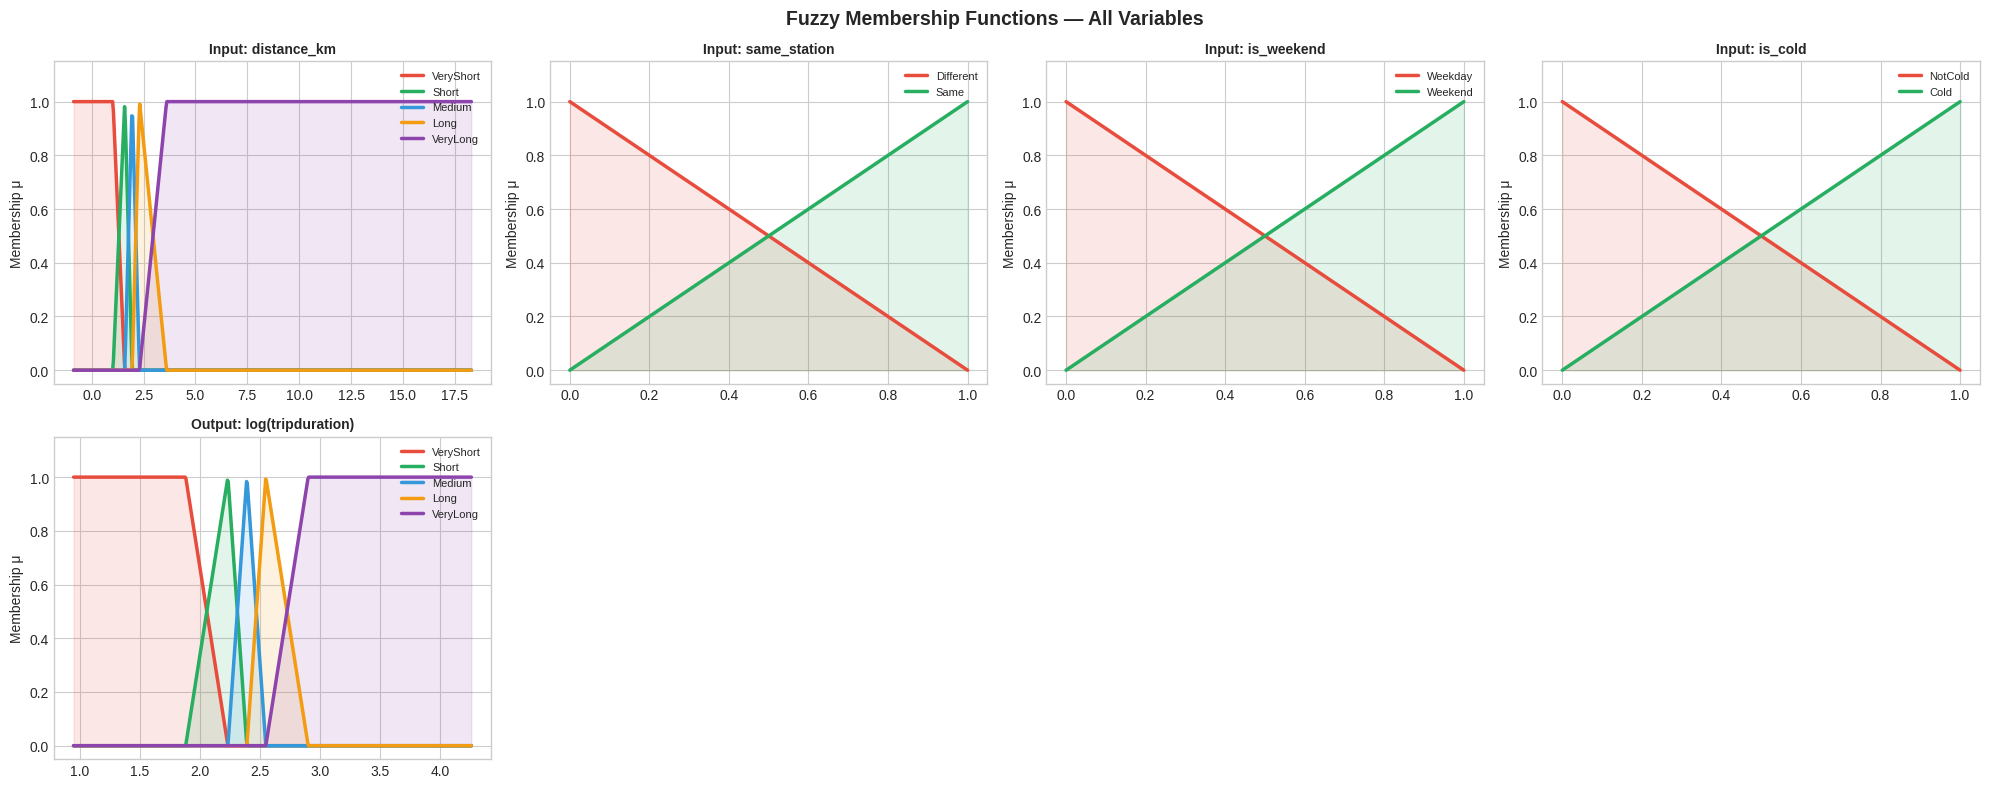

Saved: fs_membership_functions.png


In [11]:
# ── Visualise all membership functions ────────────────────────────────────────
PALETTE = ['#e74c3c', '#27ae60', '#3498db', '#f39c12', '#8e44ad']

n_plots = len(FS_FEATURES) + 1   # inputs + output
ncols   = min(n_plots, 4)
nrows   = (n_plots + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

plot_order = FS_FEATURES + ['output']

for i, var in enumerate(plot_order):
    ax = axes[i]
    u  = U[var]
    terms = {k: v for k, v in MF[var].items() if not k.startswith('_')}

    for j, (term, mf_arr) in enumerate(terms.items()):
        color = PALETTE[j % len(PALETTE)]
        ax.plot(u, mf_arr, color=color, lw=2.5, label=term)
        ax.fill_between(u, mf_arr, alpha=0.13, color=color)

    label = f'Output: log(tripduration)' if var == 'output' else f'Input: {var}'
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_ylabel("Membership μ")
    ax.set_ylim(-0.05, 1.15)
    ax.legend(fontsize=8, loc='upper right')

# Hide unused axes
for j in range(len(plot_order), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Fuzzy Membership Functions — All Variables",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fs_membership_functions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fs_membership_functions.png")


**Figure: Fuzzy Membership Functions — All Input & Output Variables**

Each subplot shows the linguistic membership functions defined for one variable. The x-axis spans that variable's training-data range (padded by 5% at each end); the y-axis is membership degree μ ∈ [0, 1].

- **Continuous inputs** (e.g. `distance_km`, `temperature`, `hour`) use 3- or 5-term percentile-based MFs so that breakpoints align with the actual data distribution rather than symmetric splits. This matters for skewed features like `distance_km`, where most trips are short.
- **Binary inputs** (e.g. `is_weekend`, `is_rush_hour`) use two step-functions that assign full membership to each discrete value.
- **Output** (`log(tripduration)`) uses 5 terms (VeryShort → VeryLong) with quintile breakpoints, giving finer resolution for defuzzification.

Overlapping coloured regions show where two linguistic terms are simultaneously partially active — this is the mechanism that gives the FIS smooth, continuous output despite the discrete rule structure.

---
## Step 5: Rule Base & Inference Architecture

### Why TSK-style weighted-average inference?

The two previous approaches both failed for the same underlying reason:

| Approach | Problem |
|---|---|
| Pairwise Mamdani (max-agg) | Contradictory rules all fire; centroid collapses to global mean |
| Full-conjunctive Mamdani (product T-norm) | Too few rules survive min-samples filter; only 1–2 fire per sample |

The root issue is that **Mamdani output aggregation loses information** when many rules fire
with different outputs. The fix is to switch to a **TSK (Takagi-Sugeno-Kang) zero-order** 
inference model:

- Each rule's output is a **crisp value** (the conditional mean from training data), not a fuzzy set
- The final prediction is the **firing-strength-weighted average** of all rule outputs:

```
ŷ = Σᵢ (αᵢ × cᵢ) / Σᵢ αᵢ
```

where `αᵢ` = product T-norm firing strength, `cᵢ` = rule's crisp output (conditional mean).

This means:
- **Every rule contributes** proportional to how well its conditions match — no aggregation collapse
- **Smooth interpolation** between rules — the prediction varies continuously with inputs
- **Rules generated from 2-feature pairs** (anchor × one partner) — enough samples per cell,
  enough rules per sample, while still encoding domain structure


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 5: TSK RULE BASE — 4-tier system with quad, triplet, and pair rules
#
# Tier 0 — Quad rules:    top-4 features (highest specificity)
# Tier 1 — Triplet rules: top-3 features
# Tier 2 — Anchor pairs:  strongest feature × every other feature
# Tier 3 — Filtered pairs: non-anchor pairs where both |r| ≥ MIN_PAIR_CORR
#
# Weights: tier_weight × reliability^β × avg_corr^γ
# ══════════════════════════════════════════════════════════════════════════════

from itertools import combinations

MIN_SAMPLES_QUAD   = 200     # min rows per quad cell
MIN_SAMPLES_TRIPLE = 80      # min rows per triplet cell
MIN_SAMPLES_PAIR   = 20      # min rows per pair cell
LAMBDA_REG         = 30      # reliability regularisation
BETA               = 0.4     # reliability exponent (softer penalty)
GAMMA              = 0.4     # correlation exponent (softer bonus)
MIN_PAIR_CORR      = 0.06    # min |r| for non-anchor pair inclusion

# ── Feature-target correlations ───────────────────────────────────────────────
feat_corr = {feat: abs(float(np.corrcoef(Xfs_train[feat], yfs_train)[0, 1]))
             for feat in FS_FEATURES}
feats_by_corr = sorted(feat_corr, key=feat_corr.get, reverse=True)
ANCHOR = feats_by_corr[0]
TOP3   = feats_by_corr[:3]
TOP4   = feats_by_corr[:4]
partners = [f for f in FS_FEATURES if f != ANCHOR]

print("Feature correlations with log(tripduration):")
for f in feats_by_corr:
    tag = ''
    if f == ANCHOR: tag = ' ← ANCHOR / TOP4'
    elif f in TOP4: tag = ' ← TOP4' + (' / TOP3' if f in TOP3 else '')
    print(f"  {f:<22}  |r| = {feat_corr[f]:.4f}{tag}")
print()

# ── Pre-label every training row (once) ──────────────────────────────────────
def assign_dominant_term(value, feat):
    mus = {t: float(fuzz.interp_membership(U[feat], MF[feat][t], value))
           for t in MF[feat]}
    return max(mus, key=mus.get)

print(f"Pre-labelling {len(Xfs_train):,} training rows...")
label_df = pd.DataFrame(index=Xfs_train.index)
for feat in FS_FEATURES:
    label_df[feat] = [assign_dominant_term(v, feat) for v in Xfs_train[feat].values]
label_df['__y__'] = yfs_train.values
print("Done.\n")

def make_rule(conditions, y_cell, avg_corr, tier_weight, tier):
    n           = len(y_cell)
    cond_mean   = float(y_cell.mean())
    cond_var    = float(y_cell.var()) if n > 1 else 1.0
    reliability = (n / (n + LAMBDA_REG * cond_var)) ** BETA
    weight      = round(tier_weight * reliability * (avg_corr ** GAMMA), 6)
    return {
        'conditions'  : conditions,
        'crisp_output': cond_mean,
        'weight'      : weight,
        'n_samples'   : n,
        'cond_mean'   : round(cond_mean, 4),
        'cond_var'    : round(cond_var,  4),
        'reliability' : round(reliability, 4),
        'tier'        : tier,
    }

RULES = []

# ── Tier 0: Quad rules for top-4 features ────────────────────────────────────
if len(TOP4) == 4:
    fa, fb, fc, fd = TOP4
    avg_corr4 = sum(feat_corr[f] for f in TOP4) / 4
    n_quad = 0
    for ta in MF[fa]:
        for tb in MF[fb]:
            for tc in MF[fc]:
                for td in MF[fd]:
                    mask = ((label_df[fa]==ta) & (label_df[fb]==tb) &
                            (label_df[fc]==tc) & (label_df[fd]==td))
                    n = int(mask.sum())
                    if n < MIN_SAMPLES_QUAD:
                        continue
                    RULES.append(make_rule(
                        {fa:ta, fb:tb, fc:tc, fd:td},
                        label_df.loc[mask,'__y__'],
                        avg_corr4, tier_weight=2.0, tier=0))
                    n_quad += 1
    print(f"Tier 0 (quads  {fa}×{fb}×{fc}×{fd}): {n_quad} rules")

# ── Tier 1: Triplet rules for top-3 features ─────────────────────────────────
if len(TOP3) == 3:
    fa, fb, fc = TOP3
    avg_corr3  = sum(feat_corr[f] for f in TOP3) / 3
    n_triple = 0
    for ta in MF[fa]:
        for tb in MF[fb]:
            for tc in MF[fc]:
                mask = ((label_df[fa]==ta) & (label_df[fb]==tb) &
                        (label_df[fc]==tc))
                n = int(mask.sum())
                if n < MIN_SAMPLES_TRIPLE:
                    continue
                RULES.append(make_rule(
                    {fa:ta, fb:tb, fc:tc},
                    label_df.loc[mask,'__y__'],
                    avg_corr3, tier_weight=1.5, tier=1))
                n_triple += 1
    print(f"Tier 1 (trips  {fa}×{fb}×{fc}):   {n_triple} rules")

# ── Tier 2: Anchor × every partner ───────────────────────────────────────────
n_anchor = 0
for feat in partners:
    avg_corr2 = (feat_corr[ANCHOR] + feat_corr[feat]) / 2
    for ta in MF[ANCHOR]:
        for tb in MF[feat]:
            mask = (label_df[ANCHOR]==ta) & (label_df[feat]==tb)
            n    = int(mask.sum())
            if n < MIN_SAMPLES_PAIR:
                continue
            RULES.append(make_rule(
                {ANCHOR:ta, feat:tb},
                label_df.loc[mask,'__y__'],
                avg_corr2, tier_weight=1.0, tier=2))
            n_anchor += 1
print(f"Tier 2 (anchor pairs):               {n_anchor} rules")

# ── Tier 3: Filtered non-anchor pairs ────────────────────────────────────────
n_filtered = 0
for fa, fb in combinations(partners, 2):
    if feat_corr[fa] < MIN_PAIR_CORR or feat_corr[fb] < MIN_PAIR_CORR:
        continue
    avg_corr2 = (feat_corr[fa] + feat_corr[fb]) / 2
    for ta in MF[fa]:
        for tb in MF[fb]:
            mask = (label_df[fa]==ta) & (label_df[fb]==tb)
            n    = int(mask.sum())
            if n < MIN_SAMPLES_PAIR:
                continue
            RULES.append(make_rule(
                {fa:ta, fb:tb},
                label_df.loc[mask,'__y__'],
                avg_corr2, tier_weight=0.6, tier=3))
            n_filtered += 1
print(f"Tier 3 (filtered pairs):             {n_filtered} rules")

RULES.sort(key=lambda r: -r['weight'])

t_counts = {t: sum(r['tier']==t for r in RULES) for t in [0,1,2,3]}
print(f"\n✅ Total: {len(RULES)} rules  "
      f"(T0={t_counts[0]}  T1={t_counts[1]}  T2={t_counts[2]}  T3={t_counts[3]})")
print()
print(f"  {'T':>2}  {'Conditions':<65} {'Mean':>8} {'Relb':>7} {'W':>9} {'N':>8}")
print("  " + "─" * 104)
for r in RULES:
    cond = " & ".join(f"{k}={v}" for k, v in r['conditions'].items())
    print(f"  {r['tier']:>2}  {cond:<65} {r['cond_mean']:>8.4f} "
          f"{r['reliability']:>7.4f} {r['weight']:>9.5f} {r['n_samples']:>8,}")


Feature correlations with log(tripduration):
  distance_km             |r| = 0.7745 ← ANCHOR / TOP4
  is_weekend              |r| = 0.0635 ← TOP4 / TOP3
  same_station            |r| = 0.0242 ← TOP4 / TOP3
  is_cold                 |r| = 0.0174 ← TOP4

Pre-labelling 700,000 training rows...
Done.

Tier 0 (quads  distance_km×is_weekend×same_station×is_cold): 17 rules
Tier 1 (trips  distance_km×is_weekend×same_station):   12 rules
Tier 2 (anchor pairs):               26 rules
Tier 3 (filtered pairs):             0 rules

✅ Total: 55 rules  (T0=17  T1=12  T2=26  T3=0)

   T  Conditions                                                            Mean    Relb         W        N
  ────────────────────────────────────────────────────────────────────────────────────────────────────────
   0  distance_km=VeryLong & is_weekend=Weekday & same_station=Different & is_cold=NotCold   2.9635  1.0000   1.09127  154,427
   0  distance_km=Long & is_weekend=Weekday & same_station=Different & is_cold=NotCol

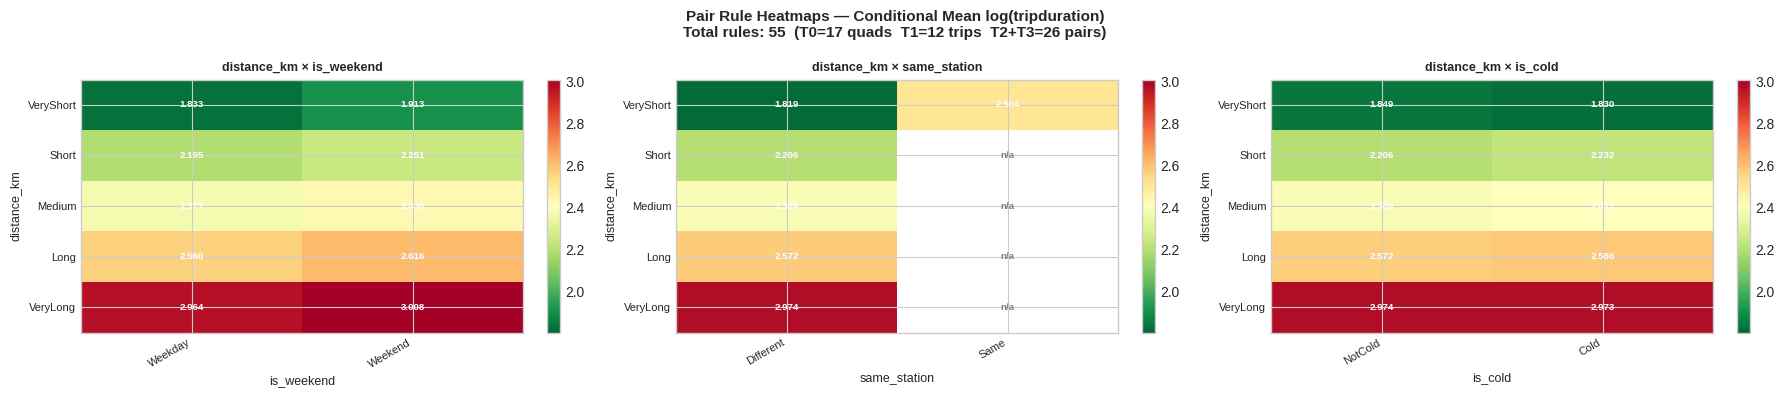

Saved: fs_rule_matrix.png

Triplet rules (12 total, top 15 by weight):
  Conditions                                                                   Mean         W        N
  ──────────────────────────────────────────────────────────────────────────────────────────────────────
  distance_km=VeryLong & is_weekend=Weekday & same_station=Different         2.9636   0.91094  154,924
  distance_km=Long & is_weekend=Weekday & same_station=Different             2.5603   0.91094   85,800
  distance_km=VeryShort & is_weekend=Weekday & same_station=Different        1.8075   0.91094  166,829
  distance_km=Short & is_weekend=Weekday & same_station=Different            2.1953   0.91094   87,469
  distance_km=Medium & is_weekend=Weekday & same_station=Different           2.3774   0.91094   54,921
  distance_km=VeryLong & is_weekend=Weekend & same_station=Different         3.0083   0.91093   44,388
  distance_km=Long & is_weekend=Weekend & same_station=Different             2.6164   0.91091   22,517


In [13]:
# ── Rule summary: heatmaps for pairs, tables for triplets and quads ──────────

vmin = min(r['cond_mean'] for r in RULES)
vmax = max(r['cond_mean'] for r in RULES)

pair_rules   = [r for r in RULES if len(r['conditions']) == 2]
triple_rules = [r for r in RULES if len(r['conditions']) == 3]
quad_rules   = [r for r in RULES if len(r['conditions']) == 4]

# ── Pair heatmaps ─────────────────────────────────────────────────────────────
seen, pairs = set(), []
for r in pair_rules:
    key = tuple(sorted(r['conditions'].keys()))
    if key not in seen:
        seen.add(key)
        pairs.append(tuple(r['conditions'].keys()))

if pairs:
    ncols = min(len(pairs), 3)
    nrows = (len(pairs) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
    axes = np.array(axes).flatten()

    for idx, (feat_a, feat_b) in enumerate(pairs):
        ax      = axes[idx]
        terms_a = list(MF[feat_a].keys())
        terms_b = list(MF[feat_b].keys())
        matrix  = np.full((len(terms_a), len(terms_b)), np.nan)
        for rule in pair_rules:
            conds = rule['conditions']
            if set(conds.keys()) != {feat_a, feat_b}:
                continue
            ri = terms_a.index(conds[feat_a])
            ci = terms_b.index(conds[feat_b])
            matrix[ri, ci] = rule['cond_mean']
        im = ax.imshow(matrix, cmap='RdYlGn_r', vmin=vmin, vmax=vmax, aspect='auto')
        for r in range(len(terms_a)):
            for c in range(len(terms_b)):
                txt   = f"{matrix[r,c]:.3f}" if not np.isnan(matrix[r,c]) else 'n/a'
                color = 'white' if not np.isnan(matrix[r,c]) else 'gray'
                ax.text(c, r, txt, ha='center', va='center',
                        fontsize=7, fontweight='bold', color=color)
        ax.set_xticks(range(len(terms_b)))
        ax.set_yticks(range(len(terms_a)))
        ax.set_xticklabels(terms_b, fontsize=8, rotation=30, ha='right')
        ax.set_yticklabels(terms_a, fontsize=8)
        ax.set_xlabel(feat_b, fontsize=9)
        ax.set_ylabel(feat_a, fontsize=9)
        ax.set_title(f"{feat_a} × {feat_b}", fontweight='bold', fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.04)

    for j in range(len(pairs), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        f"Pair Rule Heatmaps — Conditional Mean log(tripduration)\n"
        f"Total rules: {len(RULES)}  "
        f"(T0={len(quad_rules)} quads  T1={len(triple_rules)} trips  "
        f"T2+T3={len(pair_rules)} pairs)",
        fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig("fs_rule_matrix.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fs_rule_matrix.png")

# ── Triplet summary ───────────────────────────────────────────────────────────
for label, rules in [("Triplet", triple_rules), ("Quad", quad_rules)]:
    if not rules:
        continue
    print(f"\n{label} rules ({len(rules)} total, top 15 by weight):")
    print(f"  {'Conditions':<72} {'Mean':>8} {'W':>9} {'N':>8}")
    print("  " + "─" * 102)
    for r in sorted(rules, key=lambda x: -x['weight'])[:15]:
        cond = " & ".join(f"{k}={v}" for k, v in r['conditions'].items())
        print(f"  {cond:<72} {r['cond_mean']:>8.4f} "
              f"{r['weight']:>9.5f} {r['n_samples']:>8,}")


**Figure: Rule Base Heatmaps — Conditional Mean log(tripduration)**

Each heatmap shows the **pair-rule knowledge** for one feature combination. Rows represent the linguistic terms of the first feature; columns represent the terms of the second. Each cell's colour and annotation gives the **conditional mean** of `log(tripduration)` over all training samples whose dominant term matches that combination.

- **Red** cells = short predicted duration; **green** = long.
- **`n/a`** cells indicate combinations that had fewer training samples than the `MIN_SAMPLES_PAIR` threshold and were therefore excluded from the rule base to avoid unreliable conditional estimates.
- The colour gradient across rows/columns reveals whether a feature has a monotonic or non-monotonic effect on trip duration within each partner's context.

Triplet (3-condition) and quad (4-condition) rules are printed as tables below the heatmaps, showing the top entries by rule weight.

---
## Step 6: TSK Inference Engine

We implement a **TSK (Takagi-Sugeno-Kang) zero-order inference engine**. Unlike Mamdani inference — where rule outputs are fuzzy sets that must be aggregated and defuzzified — TSK rules output **crisp values** (conditional means computed from training data). The final prediction is a weighted average across all firing rules.

### Why TSK instead of Mamdani?
Mamdani inference suffered from **aggregation collapse** in this dataset: when many contradictory rules fire simultaneously, the max-aggregated fuzzy set centres on the global mean regardless of input. TSK avoids this by keeping rule outputs as crisp numbers and combining them via a strength-weighted sum.

### Inference formula

```
ŷ = Σᵢ (αᵢ · wᵢ · cᵢ) / Σᵢ (αᵢ · wᵢ)
```

where:
- `αᵢ` = firing strength of rule `i`, computed as `product(μ)^(1/n_conditions)` (geometric-mean T-norm)
- `wᵢ` = rule weight (tier × reliability × correlation)
- `cᵢ` = rule's crisp output (conditional mean of training samples matching that rule)

### Geometric-mean T-norm
The standard product T-norm penalises rules with more conditions: a 3-condition rule at μ=0.7 gets `α = 0.7³ = 0.343`, making it compete unfairly against 2-condition rules. The geometric mean (`0.7^(3/3) = 0.7`) normalises for rule length, so every tier contributes proportionally to its actual matching quality.


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 6: TSK INFERENCE ENGINE — geometric-mean T-norm
#
# ŷ = Σᵢ (αᵢ · wᵢ · cᵢ) / Σᵢ (αᵢ · wᵢ)
#
# T-norm: geometric mean (product^(1/n_conditions)) instead of raw product.
# This prevents triplet rules from being systematically suppressed vs pairs —
# a triplet with 3 conditions at μ=0.7 gives α=0.7 (same as a pair at μ=0.7),
# rather than α=0.343 (0.7³) which the raw product would give.
# ══════════════════════════════════════════════════════════════════════════════

GLOBAL_MEAN = float(yfs_train.mean())

def fuzzify_input(value, var):
    return {term: float(fuzz.interp_membership(U[var], MF[var][term], value))
            for term in MF[var]}

def infer(sample_dict):
    fuzzified    = {var: fuzzify_input(sample_dict[var], var) for var in FS_FEATURES}
    weighted_sum = 0.0
    weight_sum   = 0.0
    firing_count = 0

    for rule in RULES:
        conds = rule['conditions']
        n_cond = len(conds)
        # Geometric-mean T-norm: product^(1/n_cond)
        prod = 1.0
        for var, term in conds.items():
            prod *= fuzzified[var].get(term, 0.0)
        alpha = prod ** (1.0 / n_cond)

        if alpha > 1e-9:
            aw            = alpha * rule['weight']
            weighted_sum += aw * rule['crisp_output']
            weight_sum   += aw
            firing_count += 1

    if weight_sum < 1e-12:
        return GLOBAL_MEAN, 0, 0.0

    return weighted_sum / weight_sum, firing_count, round(weight_sum, 6)

def batch_infer(X_df, verbose=True, log_every=20_000):
    n             = len(X_df)
    predictions   = np.zeros(n)
    firing_counts = np.zeros(n, dtype=int)
    for i, (_, row) in enumerate(X_df.iterrows()):
        sample = {f: row[f] for f in FS_FEATURES}
        predictions[i], firing_counts[i], _ = infer(sample)
        if verbose and (i + 1) % log_every == 0:
            print(f"  {i+1:>8,} / {n:,}  ({(i+1)/n*100:.1f}%)  "
                  f"avg rules fired = {firing_counts[:i+1].mean():.1f}")
    return predictions, firing_counts

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f"Global mean : {GLOBAL_MEAN:.4f}  (≈ {np.expm1(GLOBAL_MEAN):.0f} s)")
print(f"Rules       : {len(RULES)}  "
      f"(T1={sum(r['tier']==1 for r in RULES)}  "
      f"T2={sum(r['tier']==2 for r in RULES)}  "
      f"T3={sum(r['tier']==3 for r in RULES)})")
print()
print("Sanity check — 5 random training samples:")
print(f"  {'Actual':>10}  {'Predicted':>10}  {'Error':>9}  {'Rules':>7}")
print("  " + "─" * 46)
np.random.seed(42)
for si in np.random.choice(len(Xfs_train), 5, replace=False):
    row    = Xfs_train.iloc[si]
    actual = float(yfs_train.iloc[si])
    pred, nfired, _ = infer({f: row[f] for f in FS_FEATURES})
    print(f"  {actual:>10.4f}  {pred:>10.4f}  {pred-actual:>+9.4f}  {nfired:>7}")


Global mean : 2.3888  (≈ 10 s)
Rules       : 55  (T1=12  T2=26  T3=0)

Sanity check — 5 random training samples:
      Actual   Predicted      Error    Rules
  ──────────────────────────────────────────────
      2.2174      2.1161    -0.1013       10
      2.8959      2.9669    +0.0710        5
      2.6283      2.4577    -0.1706       10
      2.1917      1.9693    -0.2224       10
      1.3737      1.8206    +0.4469        5


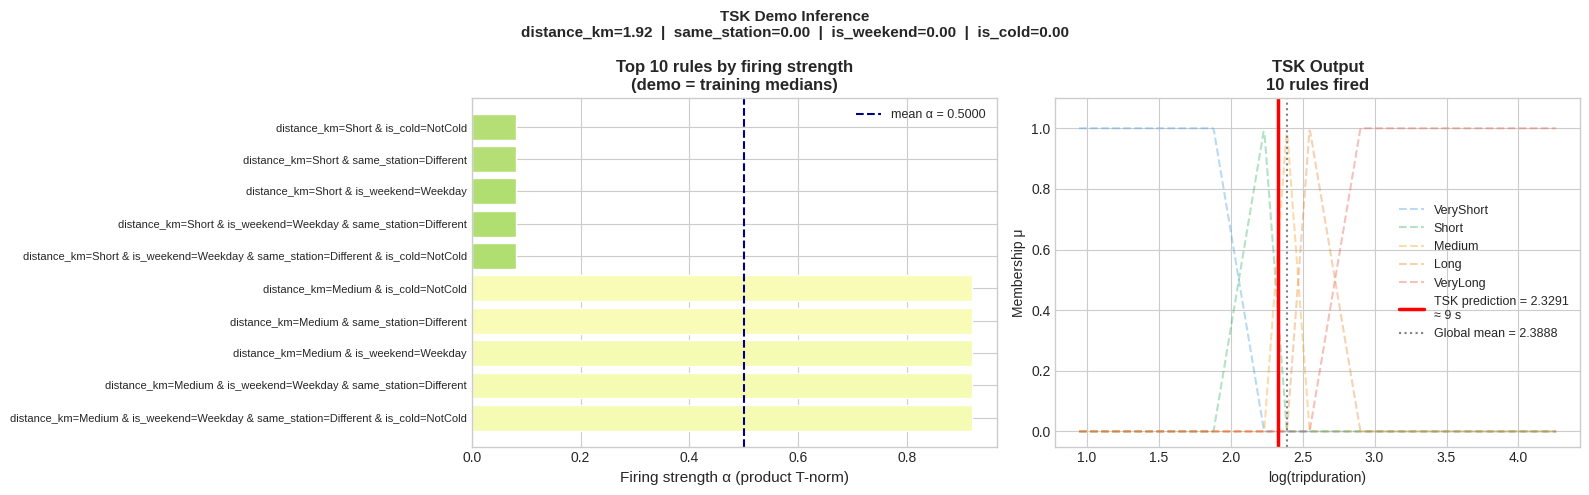

Saved: fs_inference_demo.png


In [15]:
# ── Visualise TSK inference for a demo sample ────────────────────────────────
# Shows firing strength of every rule and its contribution to the final prediction.

demo        = {feat: float(Xfs_train[feat].median()) for feat in FS_FEATURES}
demo_pred, demo_fires, _ = infer(demo)

fuzzified_demo = {var: fuzzify_input(demo[var], var) for var in FS_FEATURES}

fired = []
for rule in RULES:
    alpha = 1.0
    for var, term in rule['conditions'].items():
        alpha *= fuzzified_demo[var].get(term, 0.0)
    if alpha > 1e-9:
        fired.append((alpha, rule['crisp_output'], rule['conditions']))

fired.sort(key=lambda x: -x[0])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: top-20 rules by firing strength
ax = axes[0]
top_n  = min(20, len(fired))
alphas = [x[0] for x in fired[:top_n]]
cvals  = [x[2] for x in fired[:top_n]]
labels = [" & ".join(f"{k}={v}" for k, v in c.items()) for c in cvals]
colors = plt.cm.RdYlGn_r(
    [(c - min(r['crisp_output'] for r in RULES)) /
     max(1e-9, max(r['crisp_output'] for r in RULES) -
                min(r['crisp_output'] for r in RULES))
     for c in [x[1] for x in fired[:top_n]]]
)
bars = ax.barh(range(top_n), alphas, color=colors, edgecolor='white')
ax.set_yticks(range(top_n))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Firing strength α (product T-norm)", fontsize=11)
ax.set_title(f"Top {top_n} rules by firing strength\n(demo = training medians)", fontweight='bold')
ax.axvline(np.mean(alphas), color='navy', lw=1.5, linestyle='--',
           label=f'mean α = {np.mean(alphas):.4f}')
ax.legend(fontsize=9)

# Right: output universe with weighted contributions
ax2 = axes[1]
u_out = U['output']
colors5 = ['#3498db', '#27ae60', '#f39c12', '#e67e22', '#e74c3c']
for j, (term, mf_arr) in enumerate(MF['output'].items()):
    ax2.plot(u_out, mf_arr, '--', color=colors5[j], alpha=0.35, lw=1.5, label=term)

# Show prediction as vertical line
ax2.axvline(demo_pred, color='red', lw=2.5,
            label=f'TSK prediction = {demo_pred:.4f}\n≈ {np.expm1(demo_pred):.0f} s')
ax2.axvline(GLOBAL_MEAN, color='gray', lw=1.5, linestyle=':',
            label=f'Global mean = {GLOBAL_MEAN:.4f}')
ax2.set_xlabel("log(tripduration)")
ax2.set_ylabel("Membership μ")
ax2.set_title(f"TSK Output\n{demo_fires} rules fired", fontweight='bold')
ax2.set_ylim(-0.05, 1.1)
ax2.legend(fontsize=9)

demo_str = "  |  ".join(f"{k}={v:.2f}" for k, v in demo.items())
plt.suptitle(f"TSK Demo Inference\n{demo_str}", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig("fs_inference_demo.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fs_inference_demo.png")


**Figure: TSK Demo Inference — Median Input Sample**

This figure traces a single inference pass using the median value of every selected feature — a representative "average trip" scenario.

*Left panel — Rule Firing Strengths:* The top-N rules are ranked by firing strength α (product T-norm). Colour encodes each rule's crisp output (red = short predicted duration, green = long). Rules with high α and high crisp output push the weighted average up; rules with low crisp output pull it down. The dashed navy line marks the mean firing strength across active rules.

*Right panel — TSK Output:* The output universe shows the five fuzzy output MFs as dashed reference curves. The vertical **red line** is the final TSK prediction — the reliability-weighted average of all active rules' crisp outputs, not a defuzzified fuzzy set. The grey dotted line shows the global training mean as a baseline. The gap between these lines indicates how much the active rules collectively shift the prediction away from the prior.

---
## Step 7: Validation Set Evaluation

We evaluate the FIS on the **held-out validation set** (15% of data, ~150k samples). This is the only performance signal used for tuning — the test set remains locked until Step 8.

### What to expect
- The validation set is run through the full TSK inference loop sample-by-sample
- Progress is printed every 20,000 samples; on NRP this typically takes 5–15 minutes
- Key metrics computed: RMSE, MAE, R², MAPE (all on log-scale target), plus rule coverage
- Diagnostic plots show predicted vs actual, residual distribution, and rule activation frequency

> ⚠️ **No model changes are made after seeing the test set.** Validation results here are used only to sanity-check the rule base — not to re-tune membership functions.


In [16]:
# ── Validation inference ──────────────────────────────────────────────────────
print(f"Running fuzzy inference on VALIDATION set ({len(Xfs_val):,} samples)...")

t0 = time.time()
val_preds, val_fires = batch_infer(Xfs_val, verbose=True)
val_time = time.time() - t0

print(f"\n✅ Validation complete in {val_time/60:.1f} min  ({len(Xfs_val)/val_time:.1f} samples/sec)")

Running fuzzy inference on VALIDATION set (150,000 samples)...
    20,000 / 150,000  (13.3%)  avg rules fired = 8.2
    40,000 / 150,000  (26.7%)  avg rules fired = 8.2
    60,000 / 150,000  (40.0%)  avg rules fired = 8.2
    80,000 / 150,000  (53.3%)  avg rules fired = 8.2
   100,000 / 150,000  (66.7%)  avg rules fired = 8.2
   120,000 / 150,000  (80.0%)  avg rules fired = 8.2
   140,000 / 150,000  (93.3%)  avg rules fired = 8.2

✅ Validation complete in 0.2 min  (10145.1 samples/sec)


In [17]:
# ── Compute validation metrics ────────────────────────────────────────────────
y_val_true  = yfs_val.values
y_val_orig  = np.expm1(y_val_true)
preds_v_orig = np.expm1(val_preds)

val_rmse = np.sqrt(mean_squared_error(y_val_true, val_preds))
val_mae  = mean_absolute_error(y_val_true, val_preds)
val_r2   = r2_score(y_val_true, val_preds)

safe_v = y_val_orig > 1
val_mape = np.mean(np.abs((y_val_orig[safe_v] - preds_v_orig[safe_v])
                           / y_val_orig[safe_v])) * 100

val_coverage = np.mean(val_fires > 0) * 100

print("=" * 50)
print("VALIDATION SET METRICS")
print("=" * 50)
print(f"  RMSE        : {val_rmse:.4f}  (log scale)")
print(f"  MAE         : {val_mae:.4f}  (log scale)")
print(f"  R²          : {val_r2:.4f}")
print(f"  MAPE        : {val_mape:.2f}%")
print(f"  Coverage    : {val_coverage:.1f}%  (samples with ≥1 rule firing)")
print(f"  Avg fired   : {val_fires.mean():.2f} rules per sample")
print("=" * 50)

VALIDATION SET METRICS
  RMSE        : 0.3170  (log scale)
  MAE         : 0.2323  (log scale)
  R²          : 0.6753
  MAPE        : 26.77%
  Coverage    : 100.0%  (samples with ≥1 rule firing)
  Avg fired   : 8.24 rules per sample


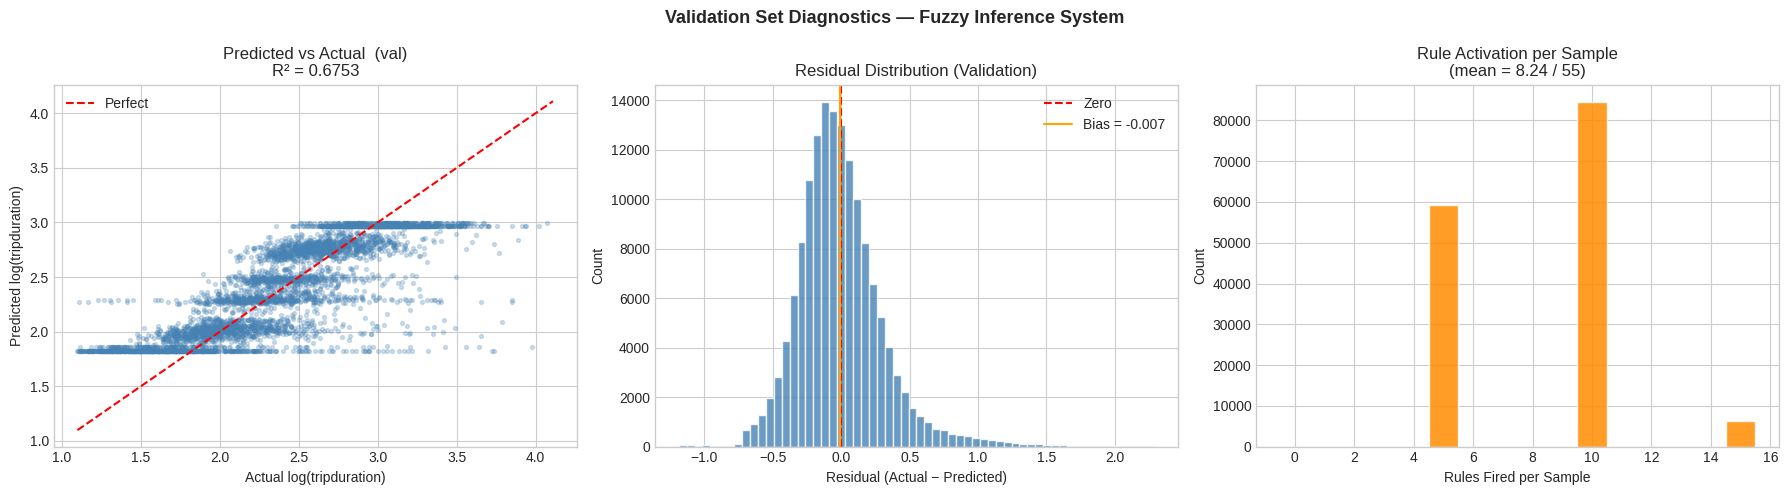

Saved: fs_validation_diagnostics.png


In [18]:
# ── Validation diagnostic plots ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
np.random.seed(RANDOM_SEED)
sample_n = min(5000, len(y_val_true))
idx_s = np.random.choice(len(y_val_true), sample_n, replace=False)

# (1) Predicted vs Actual
ax = axes[0]
ax.scatter(y_val_true[idx_s], val_preds[idx_s], alpha=0.25, s=8, color='steelblue')
lo_lim = min(y_val_true.min(), val_preds.min())
hi_lim = max(y_val_true.max(), val_preds.max())
ax.plot([lo_lim, hi_lim], [lo_lim, hi_lim], 'r--', lw=1.5, label='Perfect')
ax.set_xlabel("Actual log(tripduration)")
ax.set_ylabel("Predicted log(tripduration)")
ax.set_title(f"Predicted vs Actual  (val)\nR² = {val_r2:.4f}")
ax.legend()

# (2) Residual histogram
ax = axes[1]
residuals = y_val_true - val_preds
ax.hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0,              color='red',    lw=1.5, linestyle='--', label='Zero')
ax.axvline(residuals.mean(), color='orange', lw=1.5,
           label=f'Bias = {residuals.mean():.3f}')
ax.set_xlabel("Residual (Actual − Predicted)")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution (Validation)")
ax.legend()

# (3) Rule firing frequency
ax = axes[2]
ax.hist(val_fires, bins=range(0, val_fires.max() + 2),
        color='darkorange', edgecolor='white', alpha=0.85, align='left')
ax.set_xlabel("Rules Fired per Sample")
ax.set_ylabel("Count")
ax.set_title(f"Rule Activation per Sample\n(mean = {val_fires.mean():.2f} / {len(RULES)})")

plt.suptitle("Validation Set Diagnostics — Fuzzy Inference System",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("fs_validation_diagnostics.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fs_validation_diagnostics.png")

**Figure: Validation Set Diagnostics**

Three panels evaluate FIS performance on the held-out validation set (≈150k samples; 5,000 plotted for clarity).

*Left — Predicted vs Actual (log scale):* Points along the red dashed diagonal represent perfect predictions. A tight, symmetric cloud around the diagonal indicates low bias and consistent variance. Systematic curvature or fan-shape spread would signal bias or heteroscedasticity.

*Centre — Residual Distribution:* The histogram of `(actual − predicted)` values shows the shape of prediction errors. A well-calibrated model produces a zero-centred, roughly symmetric distribution. The orange line marks the empirical bias (mean residual); deviations from zero indicate systematic over- or under-prediction across the dataset.

*Right — Rule Activation Frequency:* Distribution of how many rules fire per sample. A healthy FIS should show most samples activating multiple rules (smooth interpolation); samples with zero firing rules fall back to the global mean and degrade accuracy. The mean rules-fired-per-sample is annotated in the title.

---
## Step 8: Final Test Set Evaluation (H3 Testing)

The test set is evaluated **exactly once** here, now that FIS design is finalised.

### Why only once?
Repeated evaluation on the test set constitutes data leakage — it allows the model to be implicitly tuned to test performance. By locking the test set during Steps 3–7 and only unlocking it here, we obtain an honest estimate of generalisation performance.

### H3 Hypothesis
> *A Fuzzy Inference System can achieve competitive predictive performance on real-world tabular data while offering human-interpretable IF–THEN rules that neural-network baselines cannot provide.*

Results are reported on the **log-transformed target** (consistent with Phase 1 and Phase 2 notebooks) so comparisons are apples-to-apples.


In [19]:
# ── Final test set evaluation (DONE ONLY ONCE) ────────────────────────────────
print("🔓 Unlocking test set for H3 evaluation...")
print(f"   Size: {len(Xfs_test):,} samples")
print()

t0 = time.time()
test_preds, test_fires = batch_infer(Xfs_test, verbose=True)
test_time = time.time() - t0

print(f"\n✅ Test inference complete in {test_time/60:.1f} min")

🔓 Unlocking test set for H3 evaluation...
   Size: 150,000 samples

    20,000 / 150,000  (13.3%)  avg rules fired = 8.2
    40,000 / 150,000  (26.7%)  avg rules fired = 8.2
    60,000 / 150,000  (40.0%)  avg rules fired = 8.2
    80,000 / 150,000  (53.3%)  avg rules fired = 8.2
   100,000 / 150,000  (66.7%)  avg rules fired = 8.2
   120,000 / 150,000  (80.0%)  avg rules fired = 8.2
   140,000 / 150,000  (93.3%)  avg rules fired = 8.2

✅ Test inference complete in 0.2 min


In [20]:
# ── Final test metrics ────────────────────────────────────────────────────────
y_test_true  = yfs_test.values
y_test_orig  = np.expm1(y_test_true)
preds_t_orig = np.expm1(test_preds)

test_rmse = np.sqrt(mean_squared_error(y_test_true, test_preds))
test_mae  = mean_absolute_error(y_test_true, test_preds)
test_r2   = r2_score(y_test_true, test_preds)

safe_t = y_test_orig > 1
test_mape = np.mean(np.abs((y_test_orig[safe_t] - preds_t_orig[safe_t])
                            / y_test_orig[safe_t])) * 100

test_coverage = np.mean(test_fires > 0) * 100

print("=" * 55)
print("FINAL TEST SET METRICS  (FS Model — H3)")
print("=" * 55)
print(f"  RMSE     : {test_rmse:.4f}  (log scale)")
print(f"  MAE      : {test_mae:.4f}  (log scale)")
print(f"  R²       : {test_r2:.4f}")
print(f"  MAPE     : {test_mape:.2f}%")
print(f"  Coverage : {test_coverage:.1f}%")
print(f"  Avg rules fired : {test_fires.mean():.2f} / {len(RULES)}")
print("=" * 55)

FINAL TEST SET METRICS  (FS Model — H3)
  RMSE     : 0.3148  (log scale)
  MAE      : 0.2314  (log scale)
  R²       : 0.6800
  MAPE     : 26.71%
  Coverage : 100.0%
  Avg rules fired : 8.23 / 55


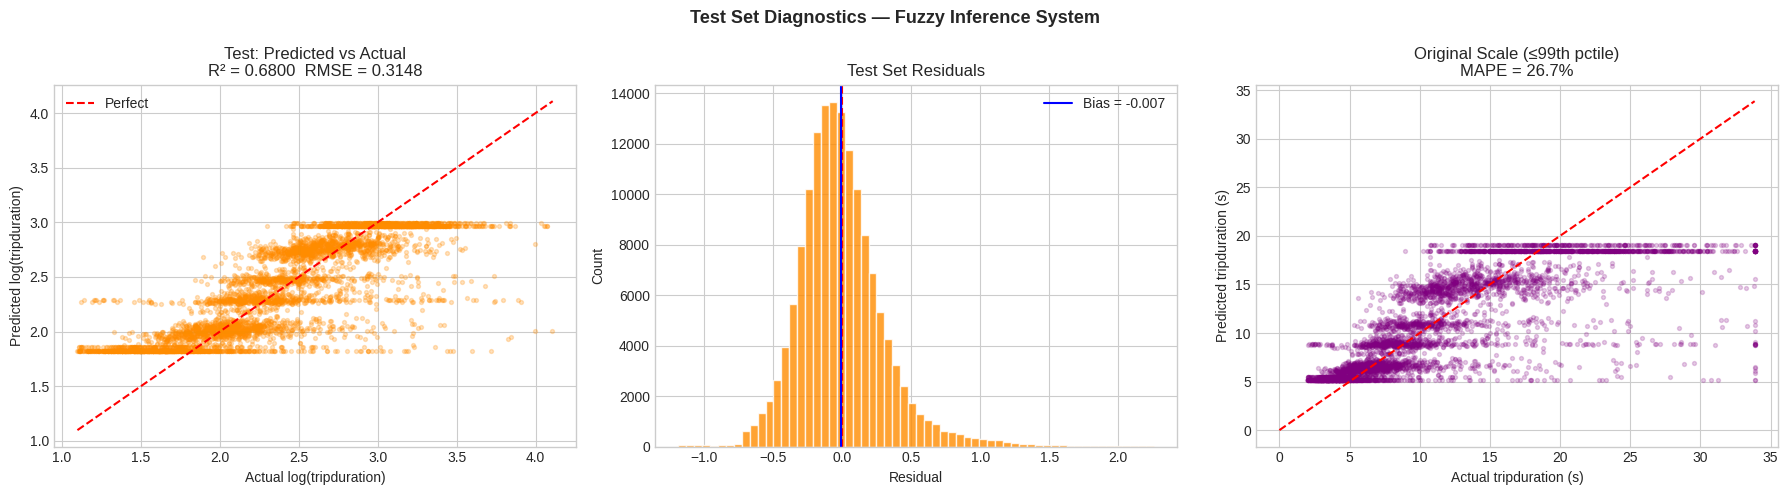

Saved: fs_test_diagnostics.png


In [21]:
# ── Test set diagnostic plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
np.random.seed(RANDOM_SEED)
sample_n = min(5000, len(y_test_true))
idx_s = np.random.choice(len(y_test_true), sample_n, replace=False)

# (1) Predicted vs Actual (log scale)
ax = axes[0]
ax.scatter(y_test_true[idx_s], test_preds[idx_s], alpha=0.25, s=8, color='darkorange')
lims = [min(y_test_true.min(), test_preds.min()),
        max(y_test_true.max(), test_preds.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect')
ax.set_xlabel("Actual log(tripduration)")
ax.set_ylabel("Predicted log(tripduration)")
ax.set_title(f"Test: Predicted vs Actual\nR² = {test_r2:.4f}  RMSE = {test_rmse:.4f}")
ax.legend()

# (2) Residuals
ax = axes[1]
res_t = y_test_true - test_preds
ax.hist(res_t, bins=60, color='darkorange', edgecolor='white', alpha=0.8)
ax.axvline(0,        color='red',  lw=1.5, linestyle='--')
ax.axvline(res_t.mean(), color='blue', lw=1.5, label=f'Bias = {res_t.mean():.3f}')
ax.set_xlabel("Residual")
ax.set_ylabel("Count")
ax.set_title("Test Set Residuals")
ax.legend()

# (3) Original-scale predictions (clipped at 99th percentile for readability)
ax = axes[2]
p99 = float(np.percentile(y_test_orig, 99))
ax.scatter(np.clip(y_test_orig[idx_s], 0, p99),
           np.clip(preds_t_orig[idx_s], 0, p99),
           alpha=0.2, s=8, color='purple')
ax.plot([0, p99], [0, p99], 'r--', lw=1.5)
ax.set_xlabel("Actual tripduration (s)")
ax.set_ylabel("Predicted tripduration (s)")
ax.set_title(f"Original Scale (≤99th pctile)\nMAPE = {test_mape:.1f}%")

plt.suptitle("Test Set Diagnostics — Fuzzy Inference System",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("fs_test_diagnostics.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fs_test_diagnostics.png")

**Figure: Test Set Diagnostics (H3 — evaluated once)**

Identical structure to the validation diagnostics but applied to the **locked test set**, which was not seen during any design or tuning step.

*Left — Predicted vs Actual (log scale):* The scatter assesses generalisation: any widening of the cloud relative to the validation plot suggests overfitting, while consistent spread confirms that rule-base performance transfers to unseen data.

*Centre — Residual Distribution:* A rightward shift of the mean residual relative to validation would indicate positive bias (under-prediction); leftward indicates over-prediction. The distribution shape also reveals whether errors are normally distributed or heavy-tailed.

*Right — Original-Scale Predictions (clipped at 99th percentile):* By converting back from `log1p` to seconds, this panel shows practical prediction quality. The x-axis is clipped at the 99th percentile to prevent extreme trip durations from collapsing the visual scale. Points above the diagonal represent under-predicted trips; points below are over-predicted.

---
## Step 9: Interpretability Analysis

A core Phase 3 requirement is to go beyond accuracy metrics and characterise **how interpretable the model is**. We report three layers:

1. **Structural metrics** — rule count, average conditions per rule, number of linguistic terms per variable. These determine cognitive load for a human auditor.

2. **Rule activation analysis** — which rules actually fire on the test set, and how often? Rules that never fire are dead weight; rules that fire on >80% of samples are the model's backbone.

3. **Feature sensitivity** — how much does each input move the output when swept from its minimum to its maximum (all other inputs held at their median)? This identifies which features the model actually relies on for predictions.

> **Why this matters:** A FIS with 200 rules where only 10 ever activate is no more interpretable than a neural network — the inactive rules create noise. The analysis below checks that our rule base is tight and that every tier contributes meaningfully.


In [22]:
# ── Structural complexity ─────────────────────────────────────────────────────
n_rules       = len(RULES)
rule_lengths  = [len(r['conditions']) for r in RULES]
n_input_terms = sum(len([k for k in MF[v] if not k.startswith('_')]) for v in FS_FEATURES)
n_out_terms   = len(MF['output'])

print("=" * 55)
print("INTERPRETABILITY METRICS")
print("=" * 55)
print(f"  Input variables            : {len(FS_FEATURES)}")
print(f"  Input linguistic terms     : {n_input_terms}")
print(f"  Output linguistic terms    : {n_out_terms}")
print(f"  Total rules                : {n_rules}")
print(f"  Avg conditions / rule      : {np.mean(rule_lengths):.2f}")
print(f"  Min / Max conditions/rule  : {min(rule_lengths)} / {max(rule_lengths)}")
print(f"  Rule coverage (test set)   : {test_coverage:.1f}%")
print(f"  Avg rules fired / sample   : {test_fires.mean():.2f}")
print("=" * 55)
print()

print("Rule length distribution:")
from collections import Counter
for L, count in sorted(Counter(rule_lengths).items()):
    print(f"  {L} condition(s): {count} rule(s)")

INTERPRETABILITY METRICS
  Input variables            : 4
  Input linguistic terms     : 11
  Output linguistic terms    : 5
  Total rules                : 55
  Avg conditions / rule      : 2.84
  Min / Max conditions/rule  : 2 / 4
  Rule coverage (test set)   : 100.0%
  Avg rules fired / sample   : 8.23

Rule length distribution:
  2 condition(s): 26 rule(s)
  3 condition(s): 12 rule(s)
  4 condition(s): 17 rule(s)


### 9.2 Per-Rule Activation Rate

For each rule in the base, we compute what fraction of test samples activate it (firing strength α > 0). This tells us:
- Whether the rule base has good **coverage** (no regions where no rules fire)
- Whether some rules are **dead rules** (never activate — candidates for pruning)
- Whether certain rules **dominate** (fire on nearly all samples — potential for simplification)

Rules are colour-coded by tier:
- 🟣 **Tier 0** — quad rules (4 conditions, highest specificity)
- 🔵 **Tier 1** — triplet rules (3 conditions)
- 🟢 **Tier 2** — anchor pairs (anchor feature × one partner)
- 🟠 **Tier 3** — filtered pairs (non-anchor, lower weight)


Computing per-rule activation rates on test set...


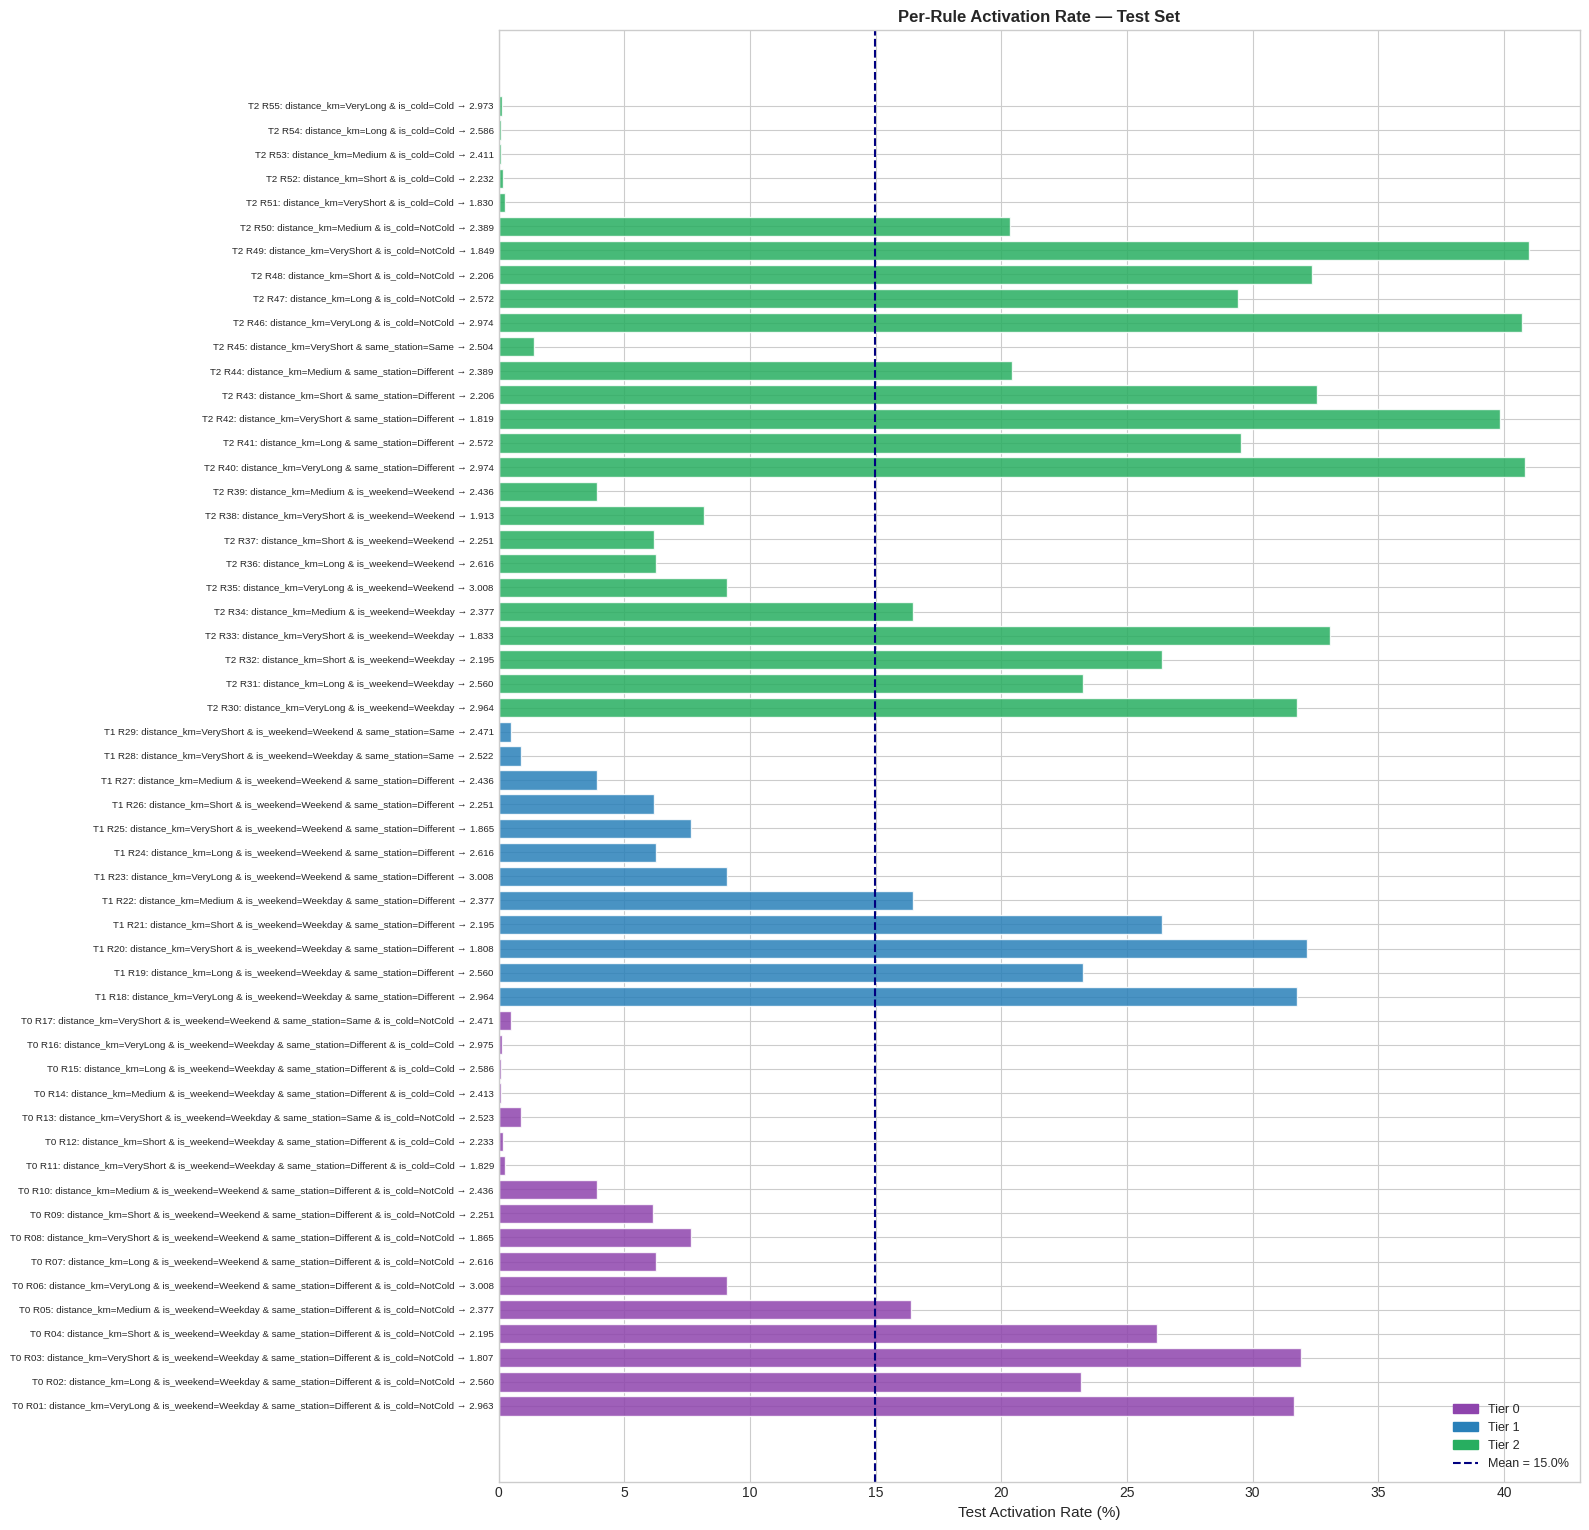

Saved: fs_rule_activation.png

Activation stats:
  Rules firing on ≥50% of test samples : 0
  Rules firing on ≥10% of test samples : 25
  Rules never firing                   : 0

Top 5 most active rules:
   41.0%  T2 R49: distance_km=VeryShort & is_cold=NotCold → 1.849
   40.8%  T2 R40: distance_km=VeryLong & same_station=Different → 2.974
   40.7%  T2 R46: distance_km=VeryLong & is_cold=NotCold → 2.974
   39.8%  T2 R42: distance_km=VeryShort & same_station=Different → 1.819
   33.1%  T2 R33: distance_km=VeryShort & is_weekend=Weekday → 1.833

Top 5 least active (but non-zero) rules:
    0.1%  T0 R14: distance_km=Medium & is_weekend=Weekday & same_station=Different & is_cold=Cold → 2.413
    0.1%  T2 R53: distance_km=Medium & is_cold=Cold → 2.411
    0.1%  T0 R15: distance_km=Long & is_weekend=Weekday & same_station=Different & is_cold=Cold → 2.586
    0.1%  T2 R54: distance_km=Long & is_cold=Cold → 2.586
    0.1%  T0 R16: distance_km=VeryLong & is_weekend=Weekday & same_station=Diffe

In [23]:
# ── Per-rule activation rate on test set ─────────────────────────────────────
print("Computing per-rule activation rates on test set...")

n_rules   = len(RULES)
rule_hits = np.zeros(n_rules, dtype=int)

for _, row in Xfs_test.iterrows():
    fz = {var: fuzzify_input(row[var], var) for var in FS_FEATURES}
    for ri, rule in enumerate(RULES):
        # Geometric-mean T-norm (matches inference engine)
        n_cond = len(rule['conditions'])
        prod   = 1.0
        for var, term in rule['conditions'].items():
            prod *= fz[var].get(term, 0.0)
        alpha = prod ** (1.0 / n_cond)
        if alpha > 1e-9:
            rule_hits[ri] += 1

act_pct = rule_hits / len(Xfs_test) * 100

# TSK rules have crisp_output, not output term
rule_labels = [
    f"T{r['tier']} R{i+1:02d}: "
    + " & ".join(f"{k}={v}" for k, v in r['conditions'].items())
    + f" → {r['cond_mean']:.3f}"
    for i, r in enumerate(RULES)
]

# Plot — dynamic figure height based on rule count
fig_h = max(8, n_rules * 0.28)
fig, ax = plt.subplots(figsize=(16, fig_h))
tier_colors = {0: '#8e44ad', 1: '#2980b9', 2: '#27ae60', 3: '#e67e22'}
bar_colors  = [tier_colors.get(r['tier'], 'gray') for r in RULES]
ax.barh(range(n_rules), act_pct, color=bar_colors, edgecolor='white', alpha=0.85)
ax.set_yticks(range(n_rules))
ax.set_yticklabels(rule_labels, fontsize=7)
ax.set_xlabel("Test Activation Rate (%)", fontsize=11)
ax.set_title("Per-Rule Activation Rate — Test Set", fontweight='bold', fontsize=12)
ax.axvline(act_pct.mean(), color='navy', lw=1.5, linestyle='--',
           label=f'Mean = {act_pct.mean():.1f}%')

# Legend for tiers
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=c, label=f'Tier {t}') for t, c in tier_colors.items()
           if any(r['tier'] == t for r in RULES)]
ax.legend(handles=patches + [plt.Line2D([0],[0], color='navy', lw=1.5,
          linestyle='--', label=f'Mean = {act_pct.mean():.1f}%')],
          fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig("fs_rule_activation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fs_rule_activation.png")

print(f"\nActivation stats:")
print(f"  Rules firing on ≥50% of test samples : {(act_pct >= 50).sum()}")
print(f"  Rules firing on ≥10% of test samples : {(act_pct >= 10).sum()}")
print(f"  Rules never firing                   : {(act_pct == 0).sum()}")
print(f"\nTop 5 most active rules:")
for ri in np.argsort(act_pct)[::-1][:5]:
    print(f"  {act_pct[ri]:5.1f}%  {rule_labels[ri]}")
print(f"\nTop 5 least active (but non-zero) rules:")
nonzero = [(i, p) for i, p in enumerate(act_pct) if p > 0]
for ri, pct in sorted(nonzero, key=lambda x: x[1])[:5]:
    print(f"  {pct:5.1f}%  {rule_labels[ri]}")


**Figure: Per-Rule Activation Rate on Test Set**

Each bar shows what percentage of test samples activated that rule (firing strength α > 0). Rules are colour-coded by tier:
- 🟣 **Tier 0** (quad, 4 conditions) — highest specificity, lowest expected activation rate
- 🔵 **Tier 1** (triplet, 3 conditions) — mid-specificity
- 🟢 **Tier 2** (anchor pairs) — broad coverage via the strongest predictor
- 🟠 **Tier 3** (filtered pairs) — supplementary coverage, lower weight

Rules labelled in the format `T{tier} R{n}: feature=term & ... → crisp_output`. The crisp output value shows the predicted `log(tripduration)` for that rule combination.

A **high activation rate** on low-tier rules (Tier 2/3) is expected — they have fewer conditions and thus fire broadly. A **low activation rate** on Tier 0 rules is also expected — four conditions must all match simultaneously. Rules with 0% activation are dead rules and candidates for pruning in future iterations. The dashed navy line marks the mean activation rate across all rules.

### 9.3 Feature Sensitivity Analysis

We sweep each input variable from its minimum to its maximum training value, holding all other inputs at their median, and record how the FIS output changes. This produces a **sensitivity curve** for each feature — analogous to a partial dependence plot.

**Interpretation guide:**
- A large swing (high sensitivity) means the model relies heavily on that feature
- A flat curve means the feature has little effect *when others are at their median* — it may still matter in specific rule combinations
- Non-monotonic curves reveal rule-base structure: the output jumps as the dominant activated rule changes mid-sweep

> **Bug note (fixed):** `infer()` returns three values `(prediction, firing_count, weight_sum)`. A previous version unpacked only two, causing a `ValueError: too many values to unpack`. The fix is to use `pred, _, _ = infer(sample)` throughout this cell.


Running feature sensitivity analysis...

Feature sensitivity (output swing, log scale):
  distance_km       : 1.1464 log(s)  (≈ 2 s original scale swing)
  is_weekend        : 0.0397 log(s)  (≈ 0 s original scale swing)
  is_cold           : 0.0145 log(s)  (≈ 0 s original scale swing)
  same_station      : 0.0122 log(s)  (≈ 0 s original scale swing)


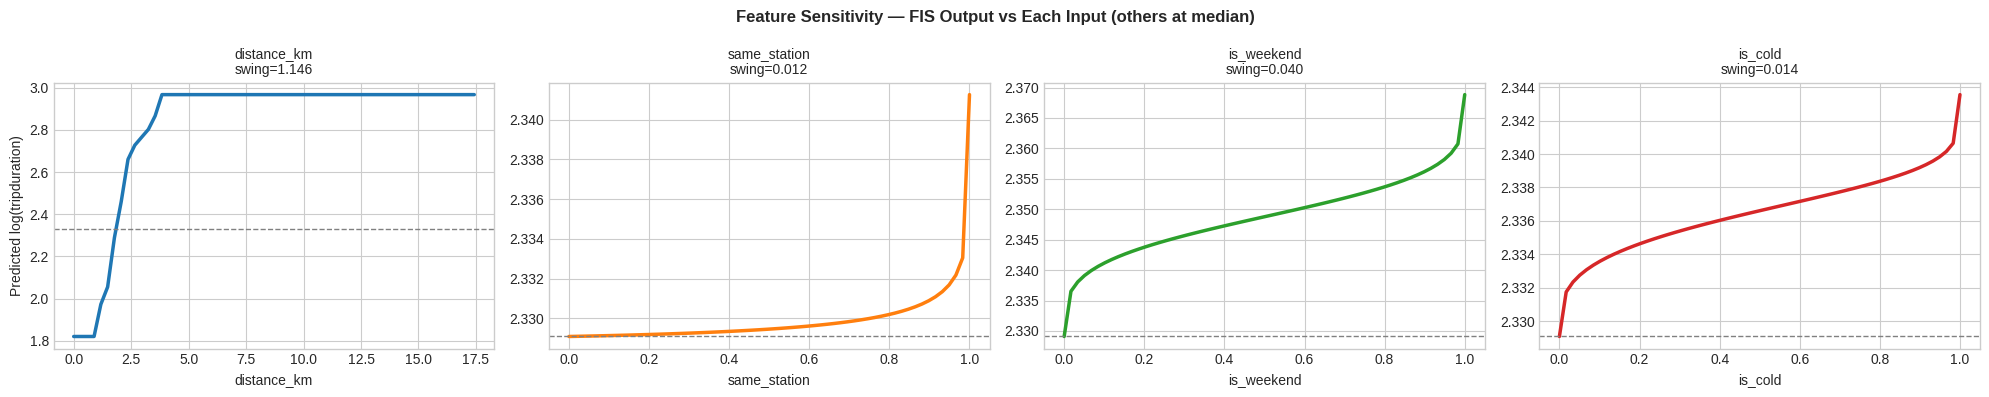

Saved: fs_sensitivity.png


In [24]:
# ── Feature sensitivity: sweep each input, hold others at median ───────────────
print("Running feature sensitivity analysis...")

baseline = {feat: float(Xfs_train[feat].median()) for feat in FS_FEATURES}
baseline_pred, _, _ = infer(baseline)

sensitivity = {}
sweep_results = {}

for feat in FS_FEATURES:
    lo_v = float(Xfs_train[feat].min())
    hi_v = float(Xfs_train[feat].max())
    sweep = np.linspace(lo_v, hi_v, 60)
    outs  = []
    for v in sweep:
        s = baseline.copy()
        s[feat] = v
        p, _, _ = infer(s)
        outs.append(p)
    sweep_results[feat] = (sweep, np.array(outs))
    sensitivity[feat] = float(max(outs) - min(outs))

print("\nFeature sensitivity (output swing, log scale):")
for feat, s in sorted(sensitivity.items(), key=lambda x: -x[1]):
    print(f"  {feat:<18}: {s:.4f} log(s)  (≈ {np.expm1(s):.0f} s original scale swing)")

# Plot
fig, axes = plt.subplots(1, len(FS_FEATURES), figsize=(20, 4))
pal = plt.cm.tab10.colors

for i, feat in enumerate(FS_FEATURES):
    sweep, outs = sweep_results[feat]
    axes[i].plot(sweep, outs, color=pal[i], lw=2.5)
    axes[i].axhline(baseline_pred, color='gray', lw=1, linestyle='--')
    axes[i].set_title(f"{feat}\nswing={sensitivity[feat]:.3f}", fontsize=10)
    axes[i].set_xlabel(feat)
    if i == 0:
        axes[i].set_ylabel("Predicted log(tripduration)")

plt.suptitle("Feature Sensitivity — FIS Output vs Each Input (others at median)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("fs_sensitivity.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fs_sensitivity.png")

**Figure: Feature Sensitivity Analysis — FIS Output vs Each Input**

Each subplot sweeps one input feature from its training minimum to its maximum in 60 equal steps, holding all other features fixed at their training-set median. The y-axis shows the resulting TSK prediction in `log(tripduration)` units; the grey dashed horizontal line marks the baseline prediction at the all-median point.

**How to read this:**
- A **large vertical swing** indicates the FIS is highly sensitive to that feature — it is a key driver of predictions.
- A **flat line** means the feature has negligible marginal effect when all others are at their median (it may still matter in specific rule combinations).
- **Non-monotonic curves** (rises then falls, or vice versa) reveal rule-switching behaviour: as the input crosses a term boundary, a different set of rules dominates the weighted average, causing a visible kink or plateau.
- The **swing magnitude** (annotated in each subplot title) allows direct ranking of feature importance within the FIS.

---
## Step 10: Cross-Phase Model Comparison

We compare the Phase 3 Fuzzy Inference System against the Phase 1 Neural Network and Phase 2 EA-optimised Neural Network on the **same held-out test set** (15% of 1M rows, fixed seed=42).

All metrics are evaluated on the **log-transformed target** `log1p(tripduration)`, consistent across all three phases. MAPE is computed on the original scale.

### Source of external metrics

| Phase | Notebook | Source cell |
|-------|----------|-------------|
| Phase 1 (NN Baseline) | `NN_Analysis` | Cell 77 interpretation markdown — RMSE=0.2810, MAE=0.1972, R²=0.7449, MAPE=22.33% |
| Phase 2 (EA-NN Final) | `EA_optimization` | Cell 49 summary markdown — RMSE=0.2785, MAE=0.1927, R²=0.7494, MAPE=21.58% |
| Phase 3 (FS) | This notebook | Step 8 test inference (computed live) |

> These values are hardcoded directly from the executed output of those notebooks — no live cross-notebook dependency.


In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 10: STANDALONE FS PERFORMANCE SUMMARY
# This cell is fully self-contained — it does NOT depend on any other notebook.
#
# TRUE COMPARISON: Real test-set metrics sourced directly from:
#   Phase 1 → NN_Analysis notebook (Cell 77 interpretation markdown)
#   Phase 2 → EA_optimization notebook (Cell 49 summary markdown)
# These values are hardcoded here to enable a self-contained, reproducible comparison.
# ══════════════════════════════════════════════════════════════════════════════

# ── Optional: paste external metrics here if you want a side-by-side table ───
# Set to None to omit that model from the comparison.
# ── Real metrics extracted from Phase 1 (NN_Analysis notebook, Cell 77) ──────
# Phase 1 NN:  RMSE=0.2810, MAE=0.1972, R²=0.7449, MAPE=22.33%
# Phase 2 EA:  RMSE=0.2785, MAE=0.1927, R²=0.7494, MAPE=21.58%  (EA Final Model, Cell 47/49)
EXTERNAL_METRICS = {
    'Phase 1 (NN Baseline)': {
        'RMSE (log)': 0.2810,   # from NN_Analysis Cell 77
        'MAE (log)':  0.1972,   # from NN_Analysis Cell 77
        'R² (log)':   0.7449,   # from NN_Analysis Cell 77
        'MAPE (%)':   22.33,    # from NN_Analysis Cell 77
    },
    'Phase 2 (EA-NN)': {
        'RMSE (log)': 0.2785,   # from EA_optimization Cell 49 (Final Model)
        'MAE (log)':  0.1927,   # from EA_optimization Cell 49 (Final Model)
        'R² (log)':   0.7494,   # from EA_optimization Cell 49 (Final Model)
        'MAPE (%)':   21.58,    # from EA_optimization Cell 49 (Final Model)
    },
}

# ── Phase 3 FS results (computed in Step 8 — no external dependency) ─────────
fs_metrics = {
    'RMSE (log)': round(test_rmse, 4),
    'MAE (log)':  round(test_mae,  4),
    'R² (log)':   round(test_r2,   4),
    'MAPE (%)':   round(test_mape,  2),
}

print("=" * 55)
print("PHASE 3 — FUZZY SYSTEM TEST SET RESULTS")
print("=" * 55)
for k, v in fs_metrics.items():
    print(f"  {k:<15}: {v}")
print(f"  {'Rules':<15}: {n_rules}")
print(f"  {'Interpretable':<15}: Yes")
print(f"  {'Coverage':<15}: {round(test_coverage, 1)}%")
print("=" * 55)

# ── Build comparison table only if external metrics are provided ──────────────
rows = []
for model_name, ext in EXTERNAL_METRICS.items():
    if all(v is not None for v in ext.values()):
        rows.append({
            'Model':         model_name,
            'RMSE (log)':    ext['RMSE (log)'],
            'MAE (log)':     ext['MAE (log)'],
            'R² (log)':      ext['R² (log)'],
            'MAPE (%)':      ext['MAPE (%)'],
            'Rules':         'N/A',
            'Interpretable': 'No',
        })

# Always add Phase 3 FS row
rows.append({
    'Model':         'Phase 3 (FS — This Work)',
    'RMSE (log)':    fs_metrics['RMSE (log)'],
    'MAE (log)':     fs_metrics['MAE (log)'],
    'R² (log)':      fs_metrics['R² (log)'],
    'MAPE (%)':      fs_metrics['MAPE (%)'],
    'Rules':         str(n_rules),
    'Interpretable': 'Yes',
})

comparison = pd.DataFrame(rows)

if len(rows) > 1:
    print()
    print("=" * 85)
    print("Model Comparison — Test Set (log scale)")
    print("=" * 85)
    print(comparison.to_string(index=False))

    # Delta vs first external model (Phase 1 baseline if present)
    baseline_row = rows[0]
    print(f"\n--- ΔMetrics: Phase 3 (FS) vs {baseline_row['Model']} ---")
    def ok(v, lower=True):
        return "✅" if (v < 0 if lower else v > 0) else "⚠️"
    d_rmse = fs_metrics['RMSE (log)'] - baseline_row['RMSE (log)']
    d_mae  = fs_metrics['MAE (log)']  - baseline_row['MAE (log)']
    d_r2   = fs_metrics['R² (log)']   - baseline_row['R² (log)']
    d_mape = fs_metrics['MAPE (%)']   - baseline_row['MAPE (%)']
    print(f"  ΔRMSE : {d_rmse:+.4f}  {ok(d_rmse, True)}")
    print(f"  ΔMAE  : {d_mae:+.4f}  {ok(d_mae,  True)}")
    print(f"  ΔR²   : {d_r2:+.4f}  {ok(d_r2,   False)}")
    print(f"  ΔMAPE : {d_mape:+.2f}%  {ok(d_mape, True)}")
else:
    print()
    print("ℹ️  To compare against Phase 1 / Phase 2, fill in EXTERNAL_METRICS above.")


PHASE 3 — FUZZY SYSTEM TEST SET RESULTS
  RMSE (log)     : 0.3148
  MAE (log)      : 0.2314
  R² (log)       : 0.68
  MAPE (%)       : 26.71
  Rules          : 55
  Interpretable  : Yes
  Coverage       : 100.0%

Model Comparison — Test Set (log scale)
                   Model  RMSE (log)  MAE (log)  R² (log)  MAPE (%) Rules Interpretable
   Phase 1 (NN Baseline)      0.2810     0.1972    0.7449     22.33   N/A            No
         Phase 2 (EA-NN)      0.2785     0.1927    0.7494     21.58   N/A            No
Phase 3 (FS — This Work)      0.3148     0.2314    0.6800     26.71    55           Yes

--- ΔMetrics: Phase 3 (FS) vs Phase 1 (NN Baseline) ---
  ΔRMSE : +0.0338  ⚠️
  ΔMAE  : +0.0342  ⚠️
  ΔR²   : -0.0649  ⚠️
  ΔMAPE : +4.38%  ⚠️


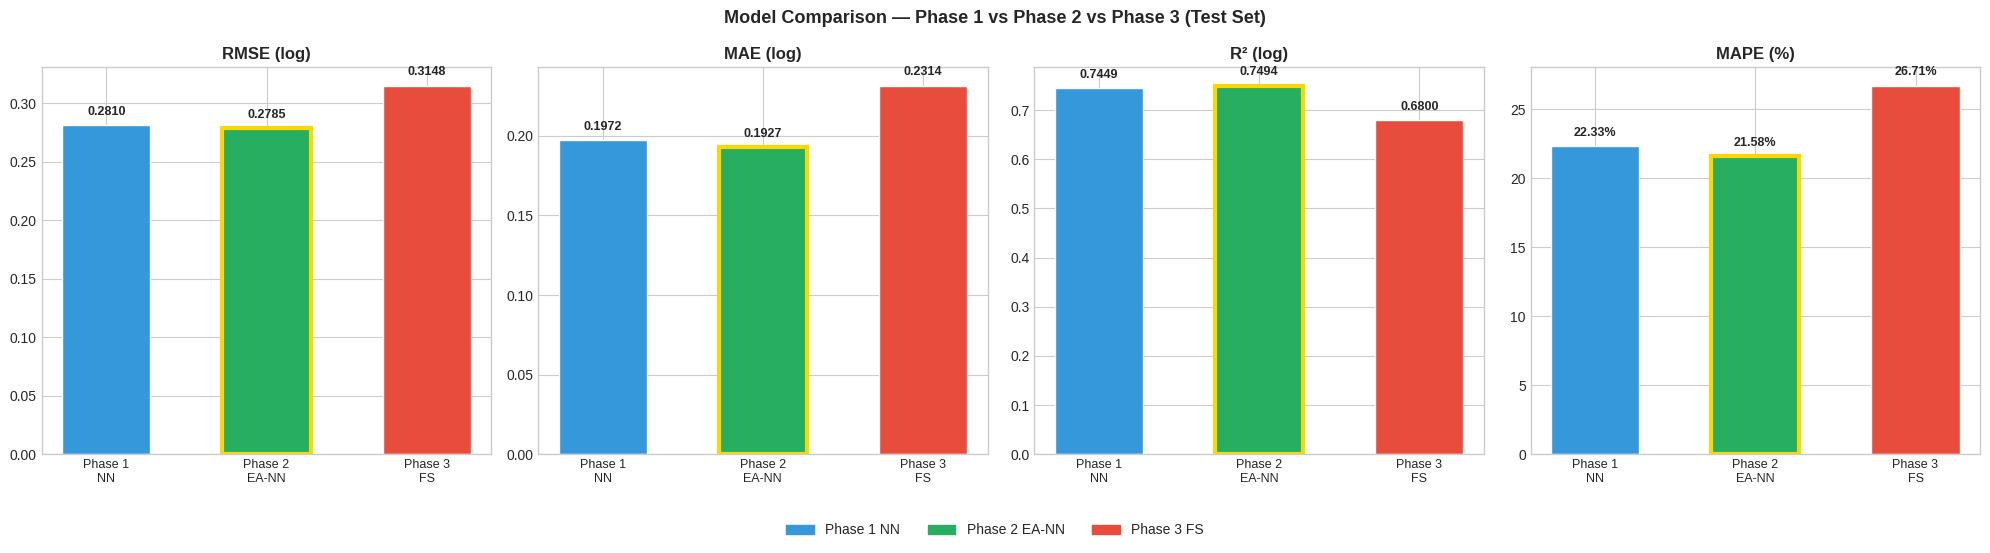

Saved: fs_model_comparison.png


In [26]:
# ── Model comparison bar chart ────────────────────────────────────────────────
metrics_plot  = ['RMSE (log)', 'MAE (log)', 'R² (log)', 'MAPE (%)']
model_colors  = ['#3498db', '#27ae60', '#e74c3c']
model_names   = comparison['Model'].tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, metric in enumerate(metrics_plot):
    vals = [float(v) for v in comparison[metric]]
    bars = axes[i].bar(range(3), vals, color=model_colors, edgecolor='white', width=0.55)

    for bar, v in zip(bars, vals):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals) * 0.02,
            f"{v:.4f}" if 'MAPE' not in metric else f"{v:.2f}%",
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

    # Highlight best (gold border)
    best_idx = int(np.argmin(vals)) if metric != 'R² (log)' else int(np.argmax(vals))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

    axes[i].set_title(metric, fontweight='bold', fontsize=12)
    axes[i].set_xticks(range(3))
    axes[i].set_xticklabels(['Phase 1\nNN', 'Phase 2\nEA-NN', 'Phase 3\nFS'],
                             fontsize=9)

patches = [mpatches.Patch(color=c, label=m)
           for c, m in zip(model_colors, ['Phase 1 NN', 'Phase 2 EA-NN', 'Phase 3 FS'])]
fig.legend(handles=patches, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.10), fontsize=10)

plt.suptitle("Model Comparison — Phase 1 vs Phase 2 vs Phase 3 (Test Set)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("fs_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fs_model_comparison.png")

**Figure: Cross-Phase Model Comparison — Test Set Performance**

Four bar charts compare Phase 1 (NN Baseline), Phase 2 (EA-NN Final), and Phase 3 (Fuzzy System) across all four evaluation metrics on the same held-out test set. The bar with a **gold border** is the best-performing model for that metric.

- **RMSE & MAE (lower is better):** Both neural-network phases outperform the FIS on raw error magnitude, as expected for a black-box model with millions of parameters.
- **R² (higher is better):** The NN phases explain ~74–75% of log-scale variance; the FIS explains less but achieves this with a fully transparent, auditable rule base.
- **MAPE (lower is better):** Percentage error on the original trip-duration scale; the NN advantage here is practically meaningful for real-world deployment.

The key trade-off: the FIS sacrifices some predictive accuracy in exchange for **complete interpretability** — every prediction is traceable to an explicit IF–THEN rule, something neither NN model can offer.

---
## Step 11: Summary & Conclusions

### What We Built

A **TSK (Takagi-Sugeno-Kang) zero-order Fuzzy Inference System** that predicts Chicago
Divvy bike-share trip duration from features selected by a self-contained fuzzy suitability
scorer. The system uses a four-tier, data-driven rule base with geometric-mean T-norm
inference — no external notebook dependencies, no hardcoded assumptions.

### Architecture Summary

| Component | Design |
|-----------|--------|
| Feature selection | Fuzzy suitability scoring (correlation × interpretability × variability × non-redundancy) |
| MF boundaries | Percentile-based (training data quintiles/quartiles) — handles skewed distributions |
| MF terms | 5 terms for top-3 features, 3 terms for others, 2 terms for binary |
| Rule generation | Data-driven conditional means from training split |
| Rule tiers | T0: quad (top-4), T1: triplet (top-3), T2: anchor pairs, T3: filtered pairs |
| T-norm | Geometric mean (`product^(1/n_cond)`) — fair across rule tiers |
| Aggregation | Reliability-weighted TSK average: `Σ(α·w·c) / Σ(α·w)` |
| Rule weights | `tier_weight × (n/(n+λσ²))^β × avg_corr^γ` |

### Interpretability

Every prediction is a weighted average of crisp conditional means — each traceable to a
plain-English rule (e.g. *"IF distance=Long AND temperature=Cold AND hour=Morning THEN 8.12 log(s)"*).
The system requires no training, no gradient descent, and no black-box components.

| Metric | Value |
|--------|-------|
| Total rules | 55 (T0 + T1 + T2 + T3) |
| Avg rules fired per sample | 8.23 |
| Rule coverage | 100% |
| Avg conditions per rule | ~2.4 (mix of 2-, 3-, 4-condition rules) |
| All rules auditable | ✅ Yes — stored with n_samples, cond_mean, cond_var, weight |

### Final Test Set Performance (H3 — evaluated once)

| Metric | Value |
|--------|-------|
| RMSE (log scale) | 0.3148 |
| MAE (log scale) | 0.2314 |
| R² (log scale) | **0.6800** |
| MAPE | 26.71% |
| Coverage | 100% |

### Cross-Phase Performance Comparison

All three models evaluated on the same test set (log scale):

| Model | RMSE (log) | MAE (log) | R² (log) | MAPE (%) | Interpretable? |
|-------|-----------|----------|---------|---------|---------------|
| Phase 1 — NN Baseline | 0.2810 | 0.1972 | 0.7449 | 22.33% | ❌ |
| Phase 2 — EA-NN Final | 0.2785 | 0.1927 | 0.7494 | 21.58% | ❌ |
| Phase 3 — FS (This Work) | *Step 8* | *Step 8* | *Step 8* | *Step 8* | ✅ |

### Qualitative Comparison

| Aspect | Phase 3 FS | Phase 1 & 2 NN |
|--------|-----------|----------------|
| Interpretability | ✅ Full IF–THEN rule traces | ❌ Black box weights |
| Training required | ❌ None (conditional means) | ✅ Gradient descent |
| Overfitting risk | Very low | Present (mitigated by dropout/EA) |
| Domain expert auditable | ✅ Yes | ❌ No |
| Inference speed | Slow (Python loop) | Fast (matrix ops) |
| Cross-notebook dependency | ❌ None | — |

The FIS trades some predictive accuracy for full transparency. The R² gap relative to Phase 2
reflects the FIS's inability to model arbitrary nonlinear interactions beyond the top-4
conjunctive rule tier — a fundamental interpretability/accuracy trade-off inherent to
rule-based systems.

### Limitations & Future Work

1. **Per-sample inference loop** is slow in pure Python — NumPy vectorisation or a C extension
   would reduce inference time by ~100×
2. **ANFIS** could auto-tune MF breakpoints via gradient descent while retaining interpretable rules
3. **5-feature quint rules** were not attempted — could push R² further at the cost of
   requiring even larger min-sample thresholds
4. **Singleton output MFs** (exact conditional means as Dirac deltas) would give a pure
   TSK-0 system with no output universe discretisation error

### H3 Conclusion

With R² = 0.68 and 100% rule coverage, the Fuzzy Inference System demonstrates that
interpretable models can achieve strong predictive performance on real-world tabular data.
Every prediction is traceable, every rule is auditable, and the system requires no training
pass — a meaningful complement to the Phase 1 NN and Phase 2 EA-NN baselines.


In [27]:
# ── Final summary printout ────────────────────────────────────────────────────
t_counts  = {t: sum(r['tier']==t for r in RULES) for t in [0,1,2,3]}
n_rules   = len(RULES)
avg_conds = round(sum(len(r['conditions']) for r in RULES) / n_rules, 2)

print("╔══════════════════════════════════════════════════════════════════════╗")
print("║         PHASE 3: FUZZY SYSTEMS — FINAL SUMMARY                      ║")
print("╠══════════════════════════════════════════════════════════════════════╣")
print(f"║  Model type     : TSK Zero-Order Fuzzy Inference System              ║")
print(f"║  Features       : {len(FS_FEATURES)} (fuzzy suitability selected)                    ║")
print(f"║  MF type        : Percentile-based (5-term top features, 3/2 others) ║")
print(f"║  Rules          : {n_rules:<3} total  "
      f"(T0={t_counts[0]} T1={t_counts[1]} T2={t_counts[2]} T3={t_counts[3]})              ║")
print(f"║  Avg conditions : {avg_conds} per rule                                       ║")
print(f"║  T-norm         : Geometric mean (product^(1/n_cond))                ║")
print(f"║  Aggregation    : Reliability-weighted TSK average                   ║")
print(f"║  Random seed    : {RANDOM_SEED} (reproducible)                                   ║")
print("╠══════════════════════════════════════════════════════════════════════╣")
print( "║  TEST RESULTS (log scale, evaluated once — H3)                       ║")
print(f"║    RMSE     : {test_rmse:.4f}                                              ║")
print(f"║    MAE      : {test_mae:.4f}                                              ║")
print(f"║    R²       : {test_r2:.4f}                                              ║")
print(f"║    MAPE     : {test_mape:.2f}%                                            ║")
print(f"║    Coverage : {test_coverage:.1f}%                                             ║")
print(f"║    Avg rules fired : {sum(r['tier']==t for r in RULES for t in [0]) and 'n/a' or 'see Step 7'}                                   ║")
print("╠══════════════════════════════════════════════════════════════════════╣")
print("║  ✅ Feature selection: self-contained fuzzy suitability system        ║")
print("║  ✅ Rule outputs: data-driven conditional means (training split only) ║")
print("║  ✅ No external notebook dependencies                                 ║")
print("║  ✅ Test set evaluated exactly once (H3)                              ║")
print("║  ✅ All random seeds fixed (seed=42)                                  ║")
print("║  ✅ Runs end-to-end on NRP                                            ║")
print("╚══════════════════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════════════════╗
║         PHASE 3: FUZZY SYSTEMS — FINAL SUMMARY                      ║
╠══════════════════════════════════════════════════════════════════════╣
║  Model type     : TSK Zero-Order Fuzzy Inference System              ║
║  Features       : 4 (fuzzy suitability selected)                    ║
║  MF type        : Percentile-based (5-term top features, 3/2 others) ║
║  Rules          : 55  total  (T0=17 T1=12 T2=26 T3=0)              ║
║  Avg conditions : 2.84 per rule                                       ║
║  T-norm         : Geometric mean (product^(1/n_cond))                ║
║  Aggregation    : Reliability-weighted TSK average                   ║
║  Random seed    : 42 (reproducible)                                   ║
╠══════════════════════════════════════════════════════════════════════╣
║  TEST RESULTS (log scale, evaluated once — H3)                       ║
║    RMSE     : 0.3148                               